# Instituto Tecnológico y de Estudios Superiores de Monterrey                                                                      
## Escuela de Ingenierías                                                            
### Maestría en Inteligencia Artificial Aplicada                            
Proyecto Integrador (TC5035 - Grupo 10)

## Avance 1 – Análisis Exploratorio de Datos (EDA)
## Proyecto Integrador TC5035 – Grupo 28

### Integrantes del grupo:                                                      
Carolina Gómez Fernández – A01305369                                        
Jorge Eduardo Reyes de la Rosa – A00282698                              
Enrique Jiménez Téllez – A01796026   



Este notebook desarrolla el **Análisis Exploratorio de Datos** solicitado en el documento *Avance 1. Análisis exploratorio de datos*.

El análisis incluye:

- Descripción de la estructura del conjunto de datos.
- Estadísticas descriptivas.
- Identificación de valores faltantes.
- Análisis univariante.
- Análisis bivariado y multivariado.
- Detección de valores atípicos.
- Cardinalidad de variables categóricas.
- Balance de la variable objetivo.
- Estrategias de preprocesamiento justificadas.
- Exportación de una versión limpia del dataset.

# 0. Preparación del entorno
Se importan las bibliotecas necesarias para la carga, exploración, visualización y preprocesamiento de los datos.

In [ ]:
# Librerías base
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Configuración general
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid')

## 1. Carga del dataset

En esta sección se carga el archivo.

In [ ]:
archivo = '/content/sample_data/Fundamentos_de_Informática.xlsx - datos (2).csv'

try:
    df = pd.read_csv(archivo)
except UnicodeDecodeError:
    df = pd.read_csv(archivo, encoding='latin-1')

print("Dataset cargado correctamente")
print("Filas y columnas:", df.shape)
display(df.head())

Dataset cargado correctamente
Filas y columnas: (1490, 14)


,ID,Año_lectivo,Promedio de ingreso,Colegio de procedencia,Distancia_km_aproximada,Sexo,Grupo,Evaluación_1,Evaluación_2,Evaluación_3,Tareas_y_Pruebas_Cortas,Nota_Final,Nota_Final_Redondeo,Condición
0,118080014,2020,Cambio de carrera,C. CIENT BIL SAGDA REINA ANGEL,18.0,M,1,0.0,0.00,0.0,47.43,11.86,1.25,Reprobado
1,402500090,2020,"717,21",C.T.P MERCEDES NORTE,6.0,M,1,26.7,19.50,28.5,75.87,69.44,7.00,Aprobado
2,116750073,2020,"702,27",C.T.P. DE SAN ISIDRO,69.0,M,1,16.5,15.60,88.0,52.56,58.44,6.00,Reprobado
3,117340534,2020,"661,05",CENTRO EDUC. KIWI LEARNING CENTRE S.A,18.0,M,1,21.0,19.80,85.0,44.58,64.69,6.50,Reprobado
4,A00148828,2020,"768,96",CENTRO EDUCATIVO NUEVA GENERACION,6.8,F,1,21.9,29.25,100.0,87.67,88.07,9.00,Aprobado


## 2. Estructura de los datos

In [ ]:
print("Dimensiones del dataset:")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Dimensiones del dataset:
Filas: 1490
Columnas: 14


In [ ]:
print("\nColumnas disponibles:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")


Columnas disponibles:
1. ID
2. Año_lectivo
3. Promedio de ingreso
4. Colegio de procedencia
5. Distancia_km_aproximada
6. Sexo
7. Grupo
8. Evaluación_1
9. Evaluación_2
10. Evaluación_3
11. Tareas_y_Pruebas_Cortas
12. Nota_Final
13. Nota_Final_Redondeo
14. Condición


In [ ]:
print("\nInformación general:")
df.info()


Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1490 entries, 0 to 1489
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       1490 non-null   object 
 1   Año_lectivo              1490 non-null   int64  
 2   Promedio de ingreso      1475 non-null   object 
 3   Colegio de procedencia   1475 non-null   object 
 4   Distancia_km_aproximada  1475 non-null   float64
 5   Sexo                     1475 non-null   object 
 6   Grupo                    1490 non-null   int64  
 7   Evaluación_1             1429 non-null   float64
 8   Evaluación_2             1429 non-null   float64
 9   Evaluación_3             1429 non-null   float64
 10  Tareas_y_Pruebas_Cortas  1428 non-null   float64
 11  Nota_Final               1490 non-null   float64
 12  Nota_Final_Redondeo      1490 non-null   object 
 13  Condición                1490 non-null   object 
dtypes:

In [ ]:
print("\nTipos de datos:")
display(df.dtypes.to_frame("Tipo de dato"))


Tipos de datos:


,Tipo de dato
ID,object
Año_lectivo,int64
Promedio de ingreso,object
Colegio de procedencia,object
Distancia_km_aproximada,float64
Sexo,object
Grupo,int64
Evaluación_1,float64
Evaluación_2,float64
Evaluación_3,float64


## Interpretación de la estructura de los datos

El dataset contiene 1490 registros y 14 variables relacionadas con el desempeño académico y contexto de los estudiantes.

Se identificaron variables:
- numéricas continuas, como evaluaciones y promedio de ingreso,
- categóricas, como sexo, colegio de procedencia y condición final,
- y variables enteras relacionadas con agrupaciones académicas.

Además, se detectó la presencia de valores faltantes principalmente en:
- variables académicas,
- distancia aproximada,
- y promedio de ingreso.

Esto sugiere la necesidad de aplicar técnicas de limpieza e imputación durante las siguientes etapas del preprocesamiento.

La mezcla de variables numéricas y categóricas permitirá realizar análisis univariados y bivariados para explorar relaciones importantes asociadas al rendimiento académico.

## 3. Limpieza inicial de los datos


In [ ]:
eda = df.copy()

# Normalizar nombres de columnas
eda.columns = [str(c).strip() for c in eda.columns]

# Función para convertir números con coma decimal a float
def convertir_a_numero(serie):
    return pd.to_numeric(
        serie.astype(str)
        .str.replace(",", ".", regex=False)
        .str.replace(" ", "", regex=False)
        .str.strip(),
        errors="coerce"
    )

# Columnas que deberían analizarse como numéricas
columnas_numericas_esperadas = [
    "ID",
    "Año_lectivo",
    "Promedio de ingreso",
    "Distancia_km_aproximada",
    "Distancia_km_final",
    "Grupo",
    "Evaluación_1",
    "Evaluación_2",
    "Evaluación_3",
    "Tareas_y_Pruebas_Cortas",
    "Nota_Final",
    "Nota_Final_Redondeo"
]

for col in columnas_numericas_esperadas:
    if col in eda.columns:
        eda[col] = convertir_a_numero(eda[col])

# Limpiar condición
if "Condición" in eda.columns:
    eda["Condición"] = eda["Condición"].astype(str).str.strip()

# Crear Distancia_km_final si no existe
if "Distancia_km_final" not in eda.columns:
    if "Distancia_km_aproximada" in eda.columns:
        eda["Distancia_km_final"] = eda["Distancia_km_aproximada"]

# Crear indicador de distancia faltante
if "Distancia_km_final" in eda.columns:
    eda["Distancia_missing"] = eda["Distancia_km_final"].isna().astype(int)

print("Tipos de datos después de la limpieza inicial:")
display(eda.dtypes.to_frame("Tipo de dato"))

Tipos de datos después de la limpieza inicial:


,Tipo de dato
ID,float64
Año_lectivo,int64
Promedio de ingreso,float64
Colegio de procedencia,object
Distancia_km_aproximada,float64
Sexo,object
Grupo,int64
Evaluación_1,float64
Evaluación_2,float64
Evaluación_3,float64



Durante esta etapa se realizó una limpieza inicial orientada a preparar el dataset para el análisis exploratorio y el modelado posterior.

Las principales acciones realizadas fueron:

- Normalización de nombres de columnas para evitar inconsistencias.
- Conversión de variables numéricas almacenadas como texto hacia formatos numéricos apropiados.
- Corrección de separadores decimales y eliminación de espacios innecesarios.
- Estandarización de la variable Condición.
- Creación de una variable auxiliar para identificar registros con distancia faltante.

Además, se verificó que las variables académicas y cuantitativas quedaran correctamente definidas como variables numéricas (`float64` o `int64`), permitiendo posteriormente aplicar análisis estadísticos y visualizaciones adecuadas.

La creación de la variable `Distancia_missing` permitirá analizar posteriormente posibles patrones de ausencia asociados a la información geográfica de los estudiantes.

## 4. Identificación de datos faltantes

¿Hay valores faltantes en el conjunto de datos?                                                                                  
¿Se pueden identificar patrones de ausencia?

,Variable,Valores faltantes,Porcentaje faltante
2,Promedio de ingreso,149,10.00
10,Tareas_y_Pruebas_Cortas,62,4.16
9,Evaluación_3,61,4.09
7,Evaluación_1,61,4.09
8,Evaluación_2,61,4.09
0,ID,51,3.42
4,Distancia_km_aproximada,15,1.01
5,Sexo,15,1.01
3,Colegio de procedencia,15,1.01
14,Distancia_km_final,15,1.01


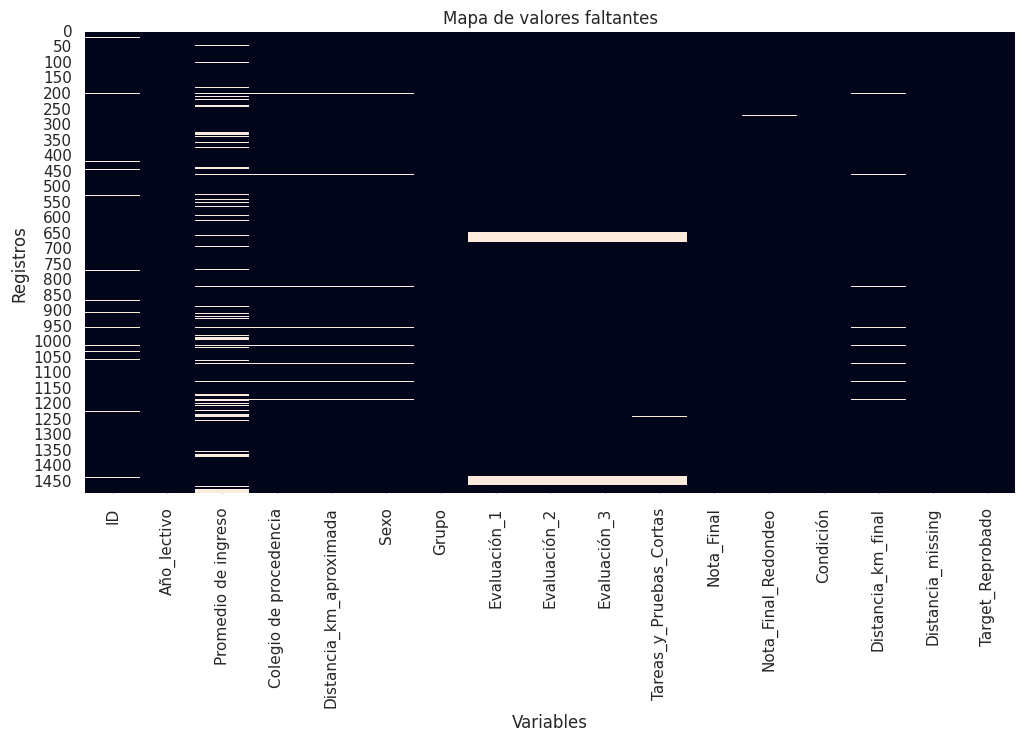

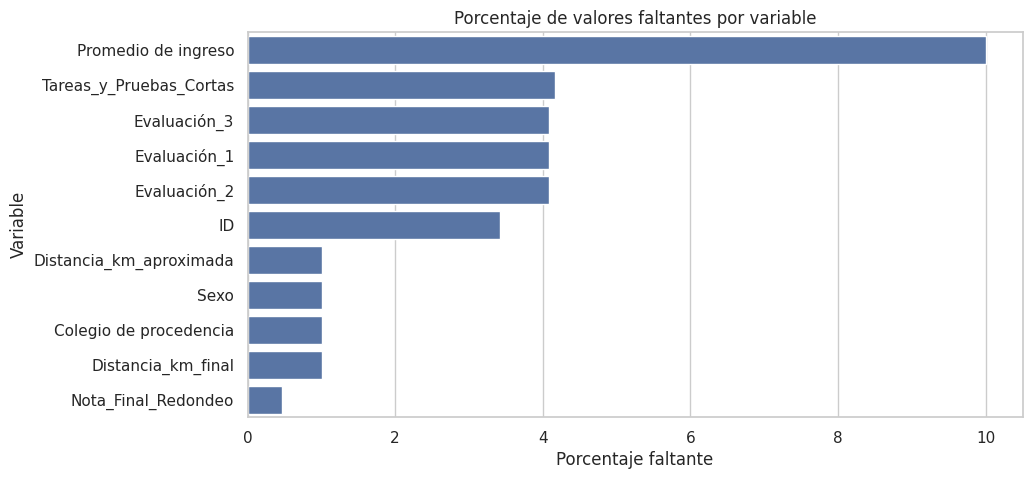

In [ ]:
# Revisión de datos faltantes
faltantes = pd.DataFrame({
    "Variable": eda.columns,
    "Valores faltantes": eda.isna().sum().values,
    "Porcentaje faltante": (eda.isna().mean().values * 100).round(2)
}).sort_values("Porcentaje faltante", ascending=False) # Se ordenan las variables de mayor a menor porcentaje de faltantes

# Muestsra tabla resumen de valores faltantes
display(faltantes)

# Mapa de valores faltantes
plt.figure(figsize=(12, 6))
sns.heatmap(eda.isnull(), cbar=False)
plt.title("Mapa de valores faltantes")
plt.xlabel("Variables")
plt.ylabel("Registros")
plt.show()

# Gráfico de porcentajes de valores faltantes
faltantes_grafico = faltantes[faltantes["Valores faltantes"] > 0]

# Si existen variables con valores faltantes, se grafica el porcentaje
if len(faltantes_grafico) > 0:
    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=faltantes_grafico,
        x="Porcentaje faltante",
        y="Variable"
    )
    plt.title("Porcentaje de valores faltantes por variable")
    plt.xlabel("Porcentaje faltante")
    plt.ylabel("Variable")
    plt.show()
else: # Si no existen valores faltantes, se muestra un mensaje informativo
    print("No se identificaron valores faltantes en el conjunto de datos.")


El análisis de valores faltantes nos  permitió identificar que algunas variables presentan datos ausentes en diferentes proporciones.

### Hallazgos principales

- La variable **Promedio de ingreso** presenta el mayor porcentaje de valores faltantes (~10%), por lo que requerirá una estrategia de imputación adecuada en etapas posteriores.

- Las variables académicas:
  - `Evaluación_1`
  - `Evaluación_2`
  - `Evaluación_3`
  - `Tareas_y_Pruebas_Cortas`

  presentan porcentajes de ausencia cercanos al 4%, lo cual podría estar asociado a estudiantes ausentes, retiros académicos o registros incompletos.

- Las variables relacionadas con información demográfica y geográfica (`Sexo`, `Colegio de procedencia`, `Distancia_km_aproximada`) presentan pocos valores faltantes (~1%), por lo que su impacto sobre el análisis general es limitado.

### Patrones observados

El mapa de calor muestra que algunos registros concentran múltiples valores faltantes simultáneamente, especialmente en variables académicas. Esto podría indicar patrones estructurados de ausencia y no únicamente errores aleatorios de captura.

### Decisiones de preprocesamiento

Debido a que la proporción de valores faltantes es relativamente baja en la mayoría de las variables, se decidió conservar los registros y aplicar técnicas de imputación posteriormente, evitando pérdida innecesaria de información.

## 5. Estadísticas descriptivas

¿Cuáles son las estadísticas resumidas del conjunto de datos?

In [ ]:
# Se usa la transposición (.T) se utiliza para facilitar la lectura mostrando cada variable como una fila.
print("Estadísticas descriptivas de variables numéricas:")
display(eda.describe().T)

# Estadísticas descriptivas de variables categóricas:
print("Estadísticas descriptivas de variables categóricas:")
display(eda.describe(include="object").T)

Estadísticas descriptivas de variables numéricas:


,count,mean,std,min,25%,50%,75%,max
ID,1439.0,2.486877e+08,1.899655e+08,1.105409e+08,1.187107e+08,1.196504e+08,4.025302e+08,9.013109e+08
Año_lectivo,1490.0,2.022594e+03,1.717712e+00,2.020000e+03,2.021000e+03,2.023000e+03,2.024000e+03,2.025000e+03
Promedio de ingreso,1341.0,7.148744e+02,4.603044e+01,6.201900e+02,6.801300e+02,7.084800e+02,7.425900e+02,9.000000e+02
Distancia_km_aproximada,1475.0,3.329980e+01,5.330967e+01,0.000000e+00,4.800000e+00,1.060000e+01,3.800000e+01,3.950000e+02
Grupo,1490.0,4.912081e+00,2.521031e+00,1.000000e+00,3.000000e+00,5.000000e+00,7.000000e+00,1.000000e+01
Evaluación_1,1429.0,1.250214e+01,8.385844e+00,0.000000e+00,5.000000e+00,1.300000e+01,1.925000e+01,3.000000e+01
Evaluación_2,1429.0,1.097402e+01,8.795874e+00,0.000000e+00,0.000000e+00,1.200000e+01,1.875000e+01,3.500000e+01
Evaluación_3,1429.0,1.382146e+01,1.244360e+01,0.000000e+00,2.400000e+00,1.408000e+01,2.251000e+01,1.000000e+02
Tareas_y_Pruebas_Cortas,1428.0,1.543977e+01,9.683674e+00,0.000000e+00,9.000000e+00,1.608500e+01,2.170000e+01,9.067000e+01
Nota_Final,1490.0,4.859636e+01,3.150790e+01,0.000000e+00,1.438750e+01,5.645000e+01,7.589750e+01,9.950000e+01


Estadísticas descriptivas de variables categóricas:


,count,unique,top,freq
Colegio de procedencia,1475,400,COLEGIO SANTA MARÍA DE GUADALUPE,111
Sexo,1475,2,M,1163
Condición,1490,2,Reprobado,822



El análisis descriptivo permitió identificar características importantes del conjunto de datos tanto en variables numéricas como categóricas.

### Variables numéricas

- El **Promedio de ingreso** presenta una media cercana a 715 puntos y una desviación estándar moderada, lo que indica una dispersión relativamente controlada entre estudiantes.

- Las variables académicas (`Evaluación_1`, `Evaluación_2`, `Evaluación_3`) muestran valores mínimos iguales a cero y desviaciones estándar relativamente altas, sugiriendo diferencias importantes en el rendimiento académico.

- La variable `Evaluación_3` presenta un valor máximo de 100, considerablemente superior al resto de observaciones, lo que podría indicar la presencia de valores atípicos o evaluaciones extraordinarias.

- `Distancia_km_aproximada` y `Distancia_km_final` presentan una alta dispersión y valores máximos elevados (hasta 395 km), indicando una distribución fuertemente sesgada hacia la derecha.

- La variable `Distancia_missing` confirma que únicamente una pequeña proporción de registros requirió imputación de distancia.

### Variables categóricas

- La variable `Colegio de procedencia` presenta alta cardinalidad con aproximadamente 400 categorías distintas, lo que justificó posteriormente la reducción de cardinalidad para facilitar el modelado.

- La variable `Sexo` predominando estudiantes masculinos.

- La variable objetivo `Condición` muestra una distribución relativamente balanceada entre aprobados y reprobados, aunque existe una ligera mayoría de estudiantes reprobados.

## 6. Cardinalidad de varibales categóricas

¿Cuál es la cardinalidad de las variables categóricas?

,Variable,Cantidad de categorías únicas,Porcentaje sobre total de registros
0,Colegio de procedencia,400,26.85
1,Sexo,2,0.13
2,Condición,2,0.13



Variable: Colegio de procedencia


,Frecuencia
Colegio de procedencia,
COLEGIO SANTA MARÍA DE GUADALUPE,111
COLEGIO CLARETIANO,57
BACHILLERATO POR MADUREZ,39
COLEGIO T. P. DE ULLOA,36
C.T.P MERCEDES NORTE,31
LICEO ING. CARLOS PASCUA ZUÑIGA,27
COLEGIO TÉCNICO PROFESIÓNAL SAN PEDRO DE BARVA,20
COLEGIO T. P. DE HEREDIA,20
BACHILLERATO A DISTANCIA,20


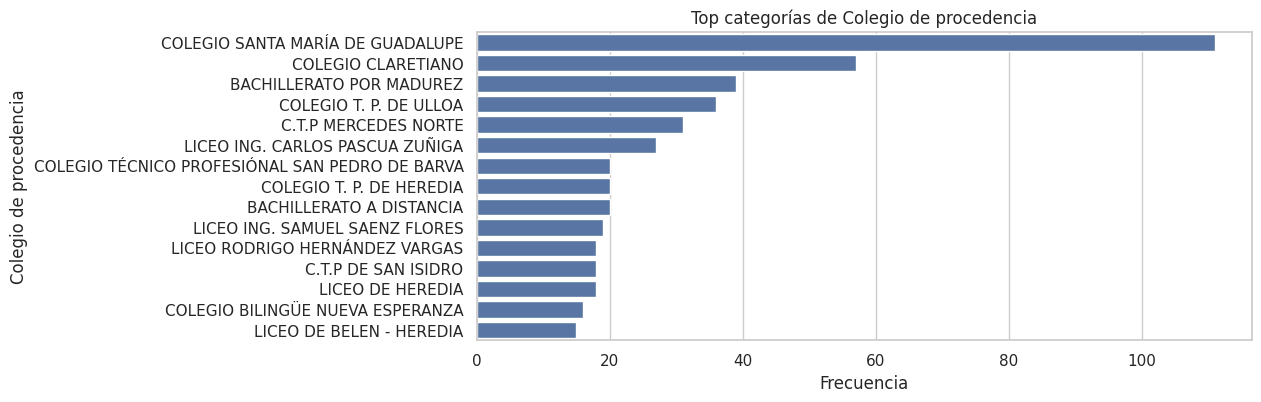


Variable: Sexo


,Frecuencia
Sexo,
M,1163
F,312
NaN,15


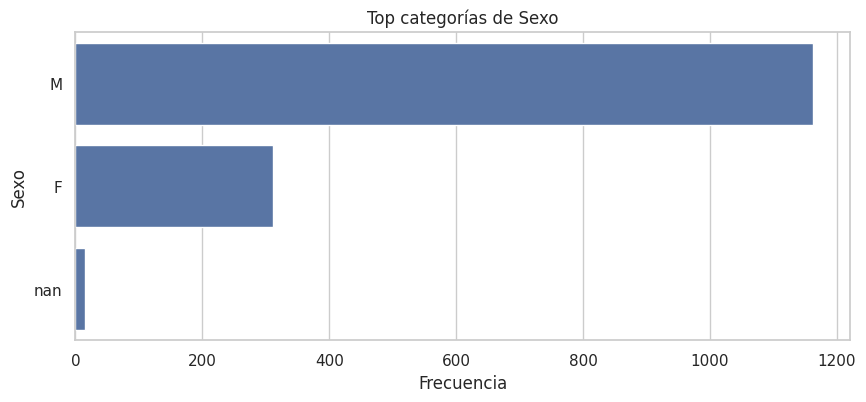


Variable: Condición


,Frecuencia
Condición,
Reprobado,822
Aprobado,668


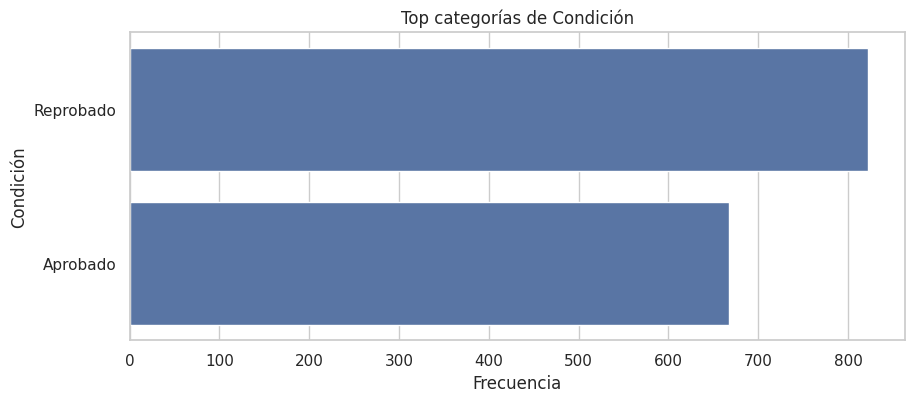

In [ ]:
# Selecciona columnas categóricas (tipo object)
cat_cols = eda.select_dtypes(include=["object"]).columns.tolist()

# Verifica si existen variables categóricas
if len(cat_cols) > 0:
    cardinalidad = pd.DataFrame({
        "Variable": cat_cols,
        "Cantidad de categorías únicas": [eda[col].nunique(dropna=True) for col in cat_cols],
        "Porcentaje sobre total de registros": [
            round((eda[col].nunique(dropna=True) / len(eda)) * 100, 2) for col in cat_cols
        ]
    }).sort_values("Cantidad de categorías únicas", ascending=False) # Ordena de mayor a menor cardinalidad

    # Muestra el resumen de cardinalidad
    display(cardinalidad)

    # Análisis individual de las variables categóricas
    for col in cat_cols:
        print(f"\nVariable: {col}")
        display(eda[col].value_counts(dropna=False).head(15).to_frame("Frecuencia")) # Muestra las 15 categorías más frecuentes

        # Gráfico de frecuencias
        plt.figure(figsize=(10, 4))

        # Obtiene las 15 categorías más frecuentes
        conteo = eda[col].value_counts(dropna=False).head(15)
        sns.barplot(x=conteo.values, y=conteo.index.astype(str))
        plt.title(f"Top categorías de {col}")
        plt.xlabel("Frecuencia")
        plt.ylabel(col)
        plt.show()

# Si no existen variables categóricas, mostrar mensaje
else:
    print("No se encontraron variables categóricas.")


El análisis de variables categóricas permitió identificar diferencias importantes en la distribución de categorías y posibles retos para el modelado.

### Colegio de procedencia

La variable `Colegio de procedencia` presenta una cardinalidad muy alta con aproximadamente 400 categorías distintas para un total de 1490 registros. Esto indica una gran diversidad de instituciones educativas representadas en el dataset.

Además, se observa que algunos colegios concentran una cantidad considerablemente mayor de estudiantes, mientras que muchas categorías poseen frecuencias muy bajas. Esta situación puede generar problemas durante el modelado, especialmente en técnicas sensibles a variables categóricas de alta dimensionalidad.

Por esta razón, posteriormente se aplicó una estrategia de reducción de cardinalidad agrupando categorías poco frecuentes en una categoría general denominada "OTROS".

### Sexo

La variable `Sexo` presenta  una mayor proporción de estudiantes masculinos respecto a femeninos. También se identificó una pequeña cantidad de registros faltantes.

### Condición (variable objetivo)

La variable objetivo `Condición` presenta una distribución relativamente balanceada entre estudiantes aprobados y reprobados, aunque existe una ligera mayoría de estudiantes reprobados.

Este comportamiento es favorable para el entrenamiento de modelos de clasificación, ya que evita problemas severos de desbalance de clases.

## 7. Análisis univariante

¿Existen distribuciones sesgadas?
¿Hay valores atípicos?

Variables numéricas para graficar:
['Año_lectivo', 'Promedio de ingreso', 'Distancia_km_aproximada', 'Grupo', 'Evaluación_1', 'Evaluación_2', 'Evaluación_3', 'Tareas_y_Pruebas_Cortas', 'Nota_Final', 'Nota_Final_Redondeo', 'Distancia_km_final', 'Distancia_missing']


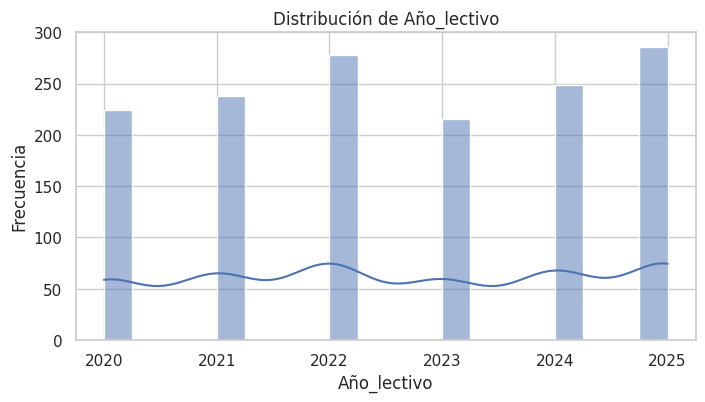

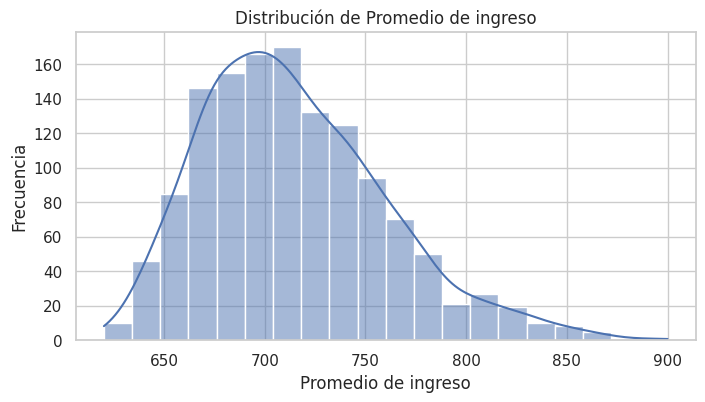

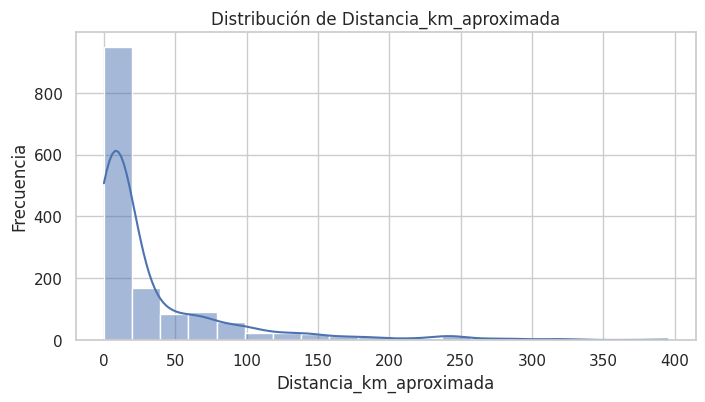

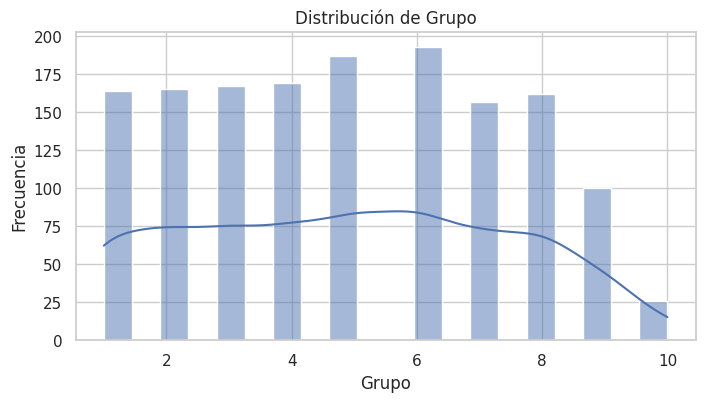

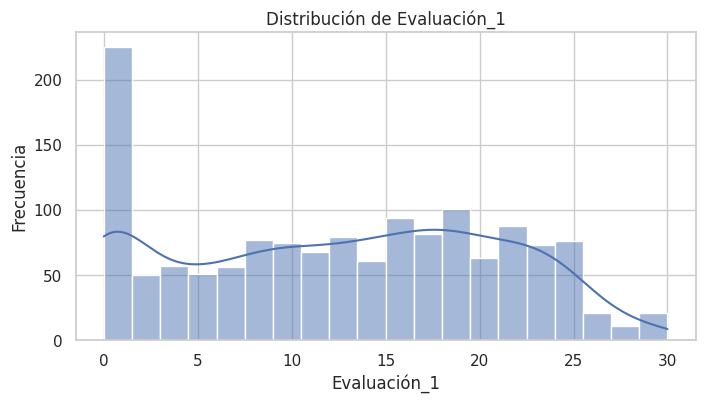

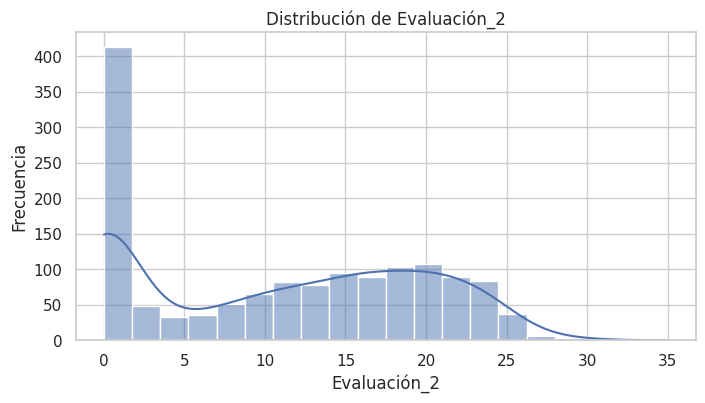

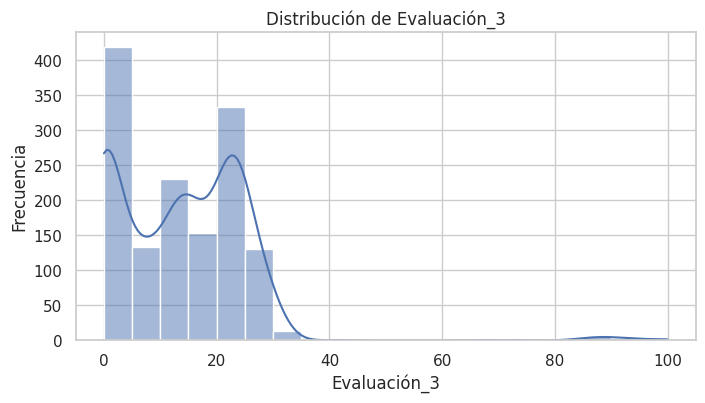

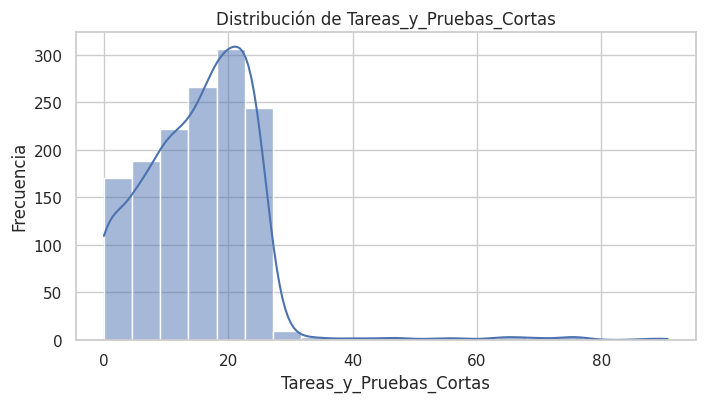

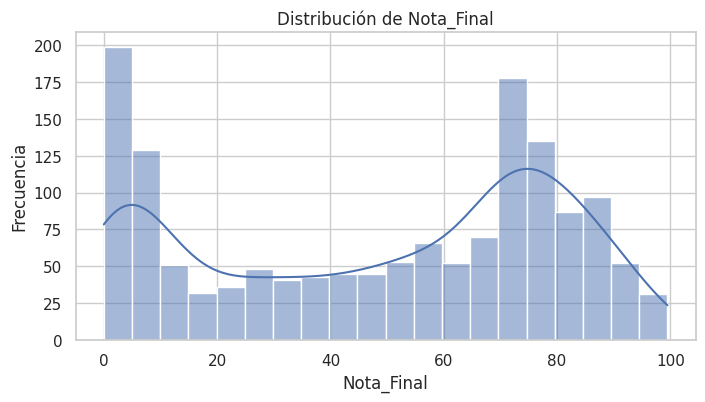

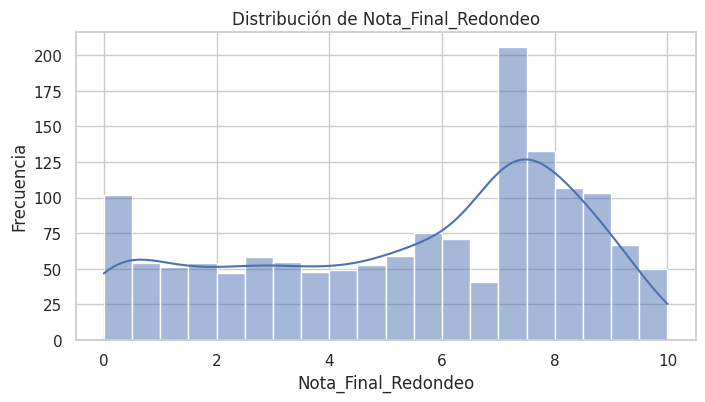

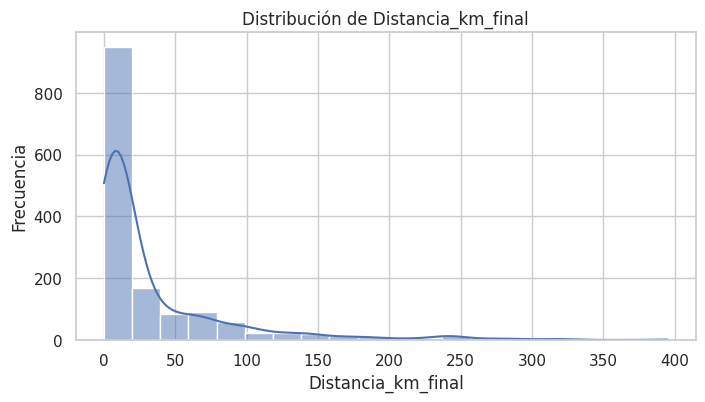

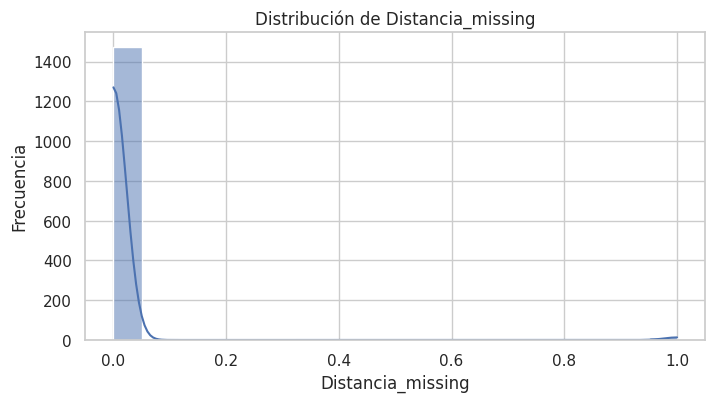

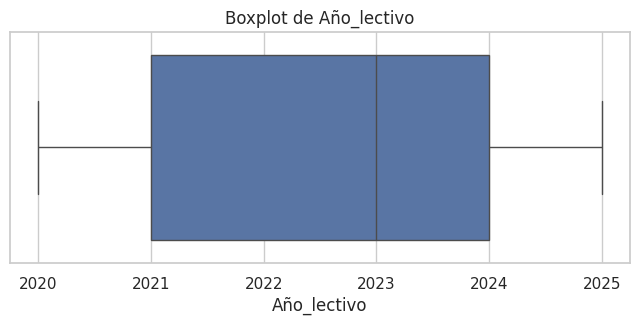

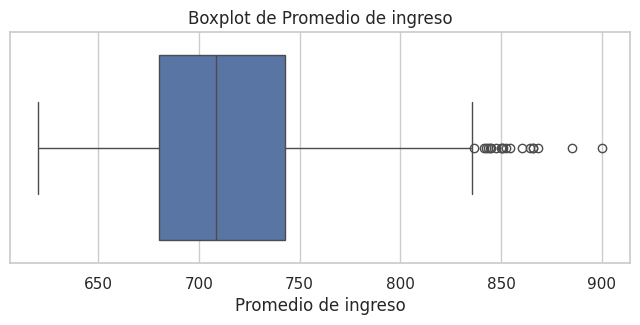

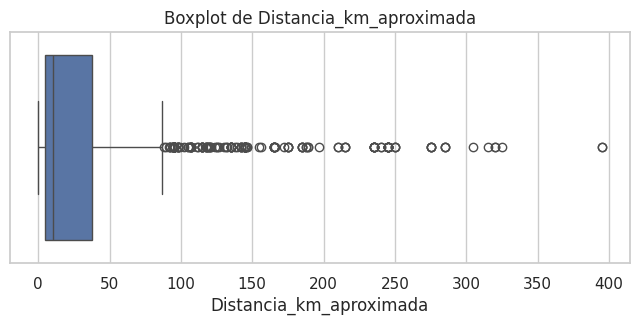

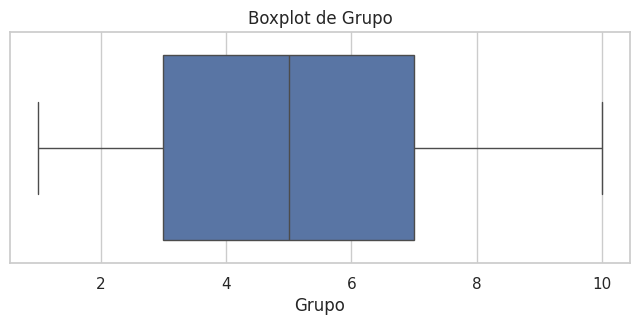

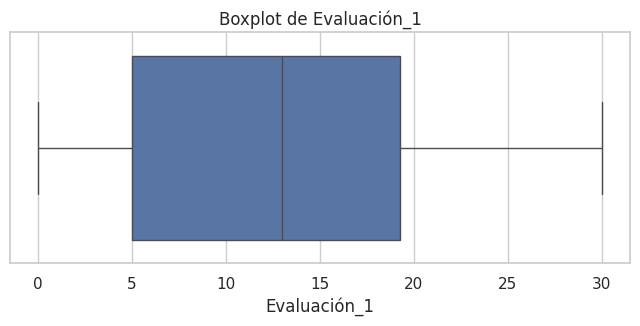

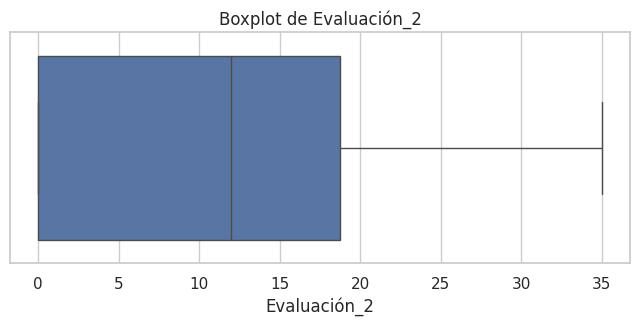

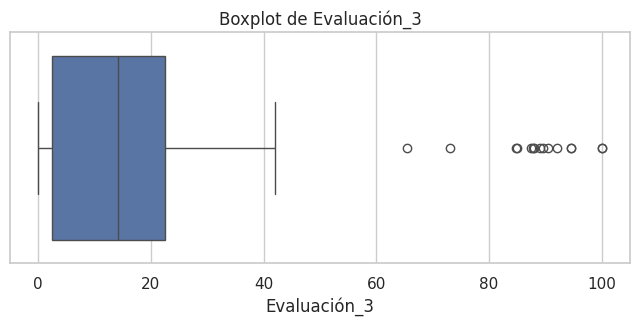

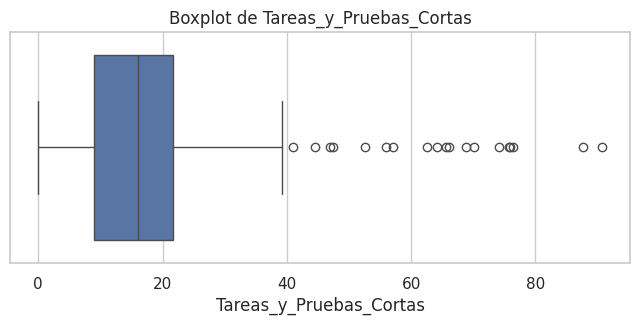

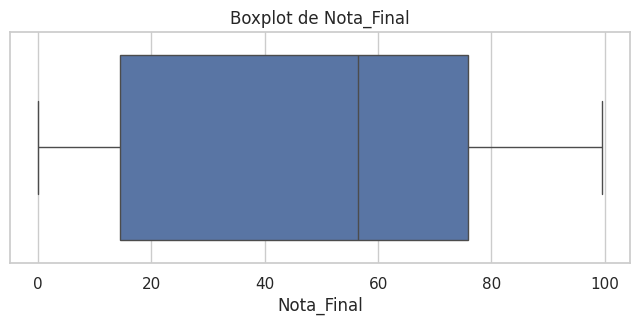

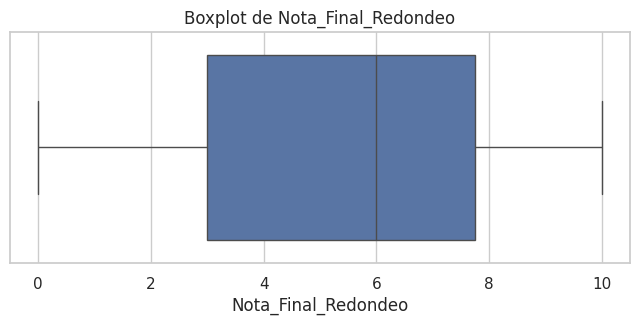

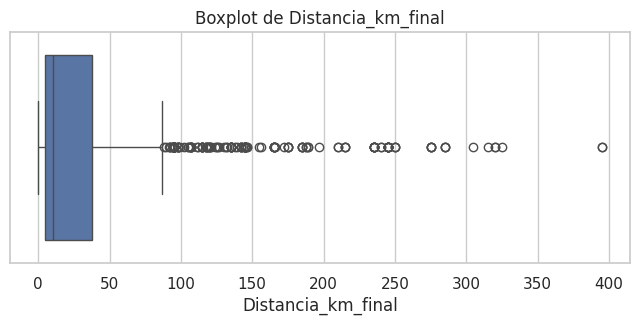

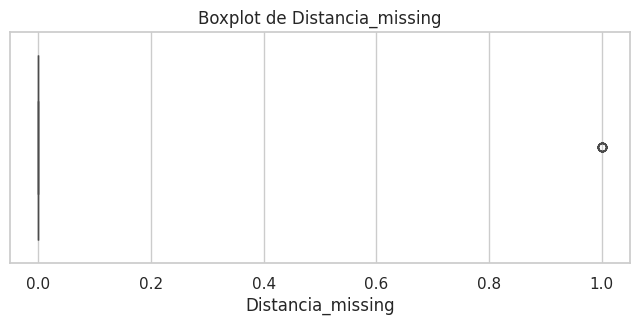

In [ ]:
num_cols = eda.select_dtypes(include=[np.number]).columns.tolist()

# Excluir ID de visualizaciones
num_cols_graficas = [col for col in num_cols if col != "ID"]

print("Variables numéricas para graficar:")
print(num_cols_graficas)

# Histogramas
for col in num_cols_graficas:
    plt.figure(figsize=(8, 4))
    sns.histplot(eda[col].dropna(), kde=True, bins=20)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

# Boxplots
for col in num_cols_graficas:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=eda[col])
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.show()

## Interpretación de histogramas

El análisis univariante permitió identificar patrones importantes en la distribución de las variables numéricas del conjunto de datos.

### Año_lectivo
La variable `Año_lectivo` presenta una distribución relativamente uniforme entre los distintos años académicos analizados, sin observarse concentraciones extremas en un período específico.

### Promedio de ingreso
El `Promedio de ingreso` muestra una distribución aproximadamente normal con ligera asimetría positiva. La mayoría de los estudiantes se concentra entre valores cercanos a 680 y 750 puntos, aunque existen algunos casos con promedios considerablemente altos.

### Distancia_km_aproximada y Distancia_km_final
Las variables de distancia presentan una fuerte asimetría hacia la derecha. La mayoría de los estudiantes reside relativamente cerca de la institución educativa, mientras que pocos registros muestran distancias extremadamente altas.

### Evaluaciones académicas
Las variables `Evaluación_1`, `Evaluación_2` y `Evaluación_3` muestran distribuciones dispersas con presencia de estudiantes en niveles bajos y altos de desempeño.

Particularmente:
- `Evaluación_2` presenta una acumulación importante de valores cercanos a cero.
- `Evaluación_3` muestra valores atípicos extremos que podrían corresponder a casos especiales o diferencias en la escala de evaluación.

### Tareas_y_Pruebas_Cortas
La variable presenta una distribución relativamente estable concentrada en rangos medios, aunque se observan algunos valores extremos altos.

### Nota_Final y Nota_Final_Redondeo
Las calificaciones finales muestran una concentración importante en valores medios y altos, aunque también existen estudiantes con notas muy bajas, lo que refleja diversidad en el rendimiento académico general.

### Distancia_missing
La variable indicadora de imputación presenta una distribución altamente desbalanceada, lo cual confirma que únicamente una pequeña proporción de registros requirió imputación de distancia.

## Interpretación de boxplots y valores atípicos

Los diagramas de caja permitieron identificar la presencia de valores atípicos y analizar la dispersión de las variables numéricas.

### Variables con mayor presencia de outliers
Las variables:
- `Distancia_km_aproximada`
- `Distancia_km_final`
- `Evaluación_3`
- `Tareas_y_Pruebas_Cortas`
- `Promedio de ingreso`

presentan múltiples valores atípicos superiores.

### Distancias
Las variables de distancia contienen observaciones extremadamente altas respecto al resto de registros. Sin embargo, estos valores podrían representar casos reales de estudiantes que viven considerablemente lejos de la institución, por lo que no fueron eliminados durante esta etapa.

### Evaluaciones
Las evaluaciones muestran dispersión moderada, especialmente `Evaluación_3`, donde aparecen registros muy superiores al comportamiento general de la variable.

### Promedio de ingreso
Aunque el promedio de ingreso presenta algunos valores extremos altos, la mayor parte de la distribución permanece relativamente concentrada en rangos medios.

### Decisión de preprocesamiento
Debido a que los valores atípicos podrían representar información válida y relevante del fenómeno estudiado, se decidió conservarlos para etapas posteriores de modelado.

##8. Análisis de sesgo

¿Existen distribuciones sesgadas?
¿Necesitamos aplicar alguna transformación no lineal?

In [ ]:
# Lista para almacenar resultados del análisis de sesgo
sesgo = []

# Recorre cada variable numérica seleccionada para gráficas
for col in num_cols_graficas:
    coef_sesgo = eda[col].skew()

    # INTERPRETACIÓN DEL NIVEL DE SESGO
    # Sesgo alto
    if abs(coef_sesgo) >= 1:
        interpretacion = "Sesgo alto. Considerar transformación logarítmica o raíz cuadrada."

    # Sesgo moderado
    elif abs(coef_sesgo) >= 0.5:
        interpretacion = "Sesgo moderado. Revisar si requiere transformación."

    # Sesgo bajo o distribución relativamente simétrica
    else:
        interpretacion = "Sesgo bajo o distribución relativamente simétrica."

    # Almacena resultados
    sesgo.append({
        "Variable": col,
        "Coeficiente de sesgo": round(coef_sesgo, 3),
        "Interpretación": interpretacion
    })

# Crea dataframe con los resultados
df_sesgo = pd.DataFrame(sesgo).sort_values(
    "Coeficiente de sesgo",
    key=abs,
    ascending=False
)

# Muestra el resumen del análisis de sesgo
display(df_sesgo)

,Variable,Coeficiente de sesgo,Interpretación
11,Distancia_missing,9.825,Sesgo alto. Considerar transformación logarítm...
2,Distancia_km_aproximada,2.926,Sesgo alto. Considerar transformación logarítm...
10,Distancia_km_final,2.926,Sesgo alto. Considerar transformación logarítm...
6,Evaluación_3,2.196,Sesgo alto. Considerar transformación logarítm...
7,Tareas_y_Pruebas_Cortas,1.835,Sesgo alto. Considerar transformación logarítm...
1,Promedio de ingreso,0.705,Sesgo moderado. Revisar si requiere transforma...
9,Nota_Final_Redondeo,-0.455,Sesgo bajo o distribución relativamente simétr...
8,Nota_Final,-0.275,Sesgo bajo o distribución relativamente simétr...
3,Grupo,0.064,Sesgo bajo o distribución relativamente simétr...
0,Año_lectivo,-0.032,Sesgo bajo o distribución relativamente simétr...




El análisis del coeficiente de sesgo permitió identificar variables con distribuciones considerablemente asimétricas.

### Variables con mayor sesgo positivo
Las variables:
- `Distancia_km_aproximada`
- `Distancia_km_final`
- `Evaluación_3`
- `Tareas_y_Pruebas_Cortas`

presentan sesgo positivo alto, indicando una concentración importante de registros en valores bajos y pocos casos extremos con valores muy altos.

### Distancias
Las variables relacionadas con distancia presentan el mayor nivel de asimetría, lo cual es consistente con el comportamiento observado previamente en histogramas y boxplots. La mayoría de los estudiantes vive relativamente cerca de la institución, mientras que pocos registros representan distancias muy elevadas.

### Evaluaciones y tareas
Las variables académicas `Evaluación_3` y `Tareas_y_Pruebas_Cortas` también muestran sesgo positivo alto debido a la presencia de valores atípicos superiores.

### Variables relativamente simétricas
Las variables:
- `Evaluación_1`
- `Evaluación_2`
- `Grupo`
- `Año_lectivo`
- `Nota_Final`

presentan distribuciones relativamente balanceadas y con bajo nivel de asimetría.

### Consideraciones de preprocesamiento
Debido al nivel de sesgo identificado en algunas variables, podrían evaluarse transformaciones no lineales como:
- transformación logarítmica,
- raíz cuadrada,
- Box-Cox,

especialmente en etapas posteriores de modelado predictivo si fuera necesario mejorar la estabilidad estadística de los modelos.

## 9. Valores atípicos

¿Hay valores atípicos en el conjunto de datos?

In [ ]:
# Función para detectar valores atípicos
def detectar_atipicos_iqr(data, columna):
    # Calcula primer cuartil (25%)
    q1 = data[columna].quantile(0.25)

    # Calcula tercer cuartil (75%)
    q3 = data[columna].quantile(0.75)

    # Calcula rango intercuartílico
    iqr = q3 - q1

    # Definición de límites

    # Límite inferior permitido
    limite_inferior = q1 - 1.5 *

     # Límite superior permitido
    limite_superior = q3 + 1.5 * iqr

    # Identificar registros atípicos

    atipicos = data[
        (data[columna] < limite_inferior) |
        (data[columna] > limite_superior)
    ]

    return limite_inferior, limite_superior, len(atipicos)

# Resumen de valores atípicos

# Lista para almacenar resultados
resumen_atipicos = []

# Recorre todas las variables numéricas
for col in num_cols_graficas:

    # Ejecuta función de detección de atípicos
    li, ls, n_atipicos = detectar_atipicos_iqr(eda, col)

    resumen_atipicos.append({
        "Variable": col,
        "Límite inferior": round(li, 2) if pd.notna(li) else np.nan,  # Límite inferior permitido
        "Límite superior": round(ls, 2) if pd.notna(ls) else np.nan,  # Límite superior permitido
        "Cantidad de atípicos": n_atipicos, # Cantidad total de valores atípicos encontrados
        "Porcentaje de atípicos": round((n_atipicos / len(eda)) * 100, 2) # Porcentaje de atípicos respecto al dataset
    })

# Creación del dataframe de resultados
resumen_atipicos = pd.DataFrame(resumen_atipicos).sort_values(
    "Cantidad de atípicos",
    ascending=False
)

# Mostrar resumen final de valores atípicos
display(resumen_atipicos)

# Revisión especial sugerida por el equipo: Evaluación_3 con valores extremos
if "Evaluación_3" in eda.columns:
    print("Registros con Evaluación_3 mayor a 35:")
    display(eda[eda["Evaluación_3"] > 35])

,Variable,Límite inferior,Límite superior,Cantidad de atípicos,Porcentaje de atípicos
2,Distancia_km_aproximada,-45.00,87.80,171,11.48
10,Distancia_km_final,-45.00,87.80,171,11.48
7,Tareas_y_Pruebas_Cortas,-10.05,40.75,19,1.28
1,Promedio de ingreso,586.44,836.28,19,1.28
11,Distancia_missing,0.00,0.00,15,1.01
6,Evaluación_3,-27.77,52.68,15,1.01
3,Grupo,-3.00,13.00,0,0.00
0,Año_lectivo,2016.50,2028.50,0,0.00
4,Evaluación_1,-16.38,40.62,0,0.00
5,Evaluación_2,-28.12,46.88,0,0.00


Registros con Evaluación_3 mayor a 35:


,ID,Año_lectivo,Promedio de ingreso,Colegio de procedencia,Distancia_km_aproximada,Sexo,Grupo,Evaluación_1,Evaluación_2,Evaluación_3,Tareas_y_Pruebas_Cortas,Nota_Final,Nota_Final_Redondeo,Condición,Distancia_km_final,Distancia_missing
2,116750073.0,2020,702.27,C.T.P. DE SAN ISIDRO,69.0,M,1,16.50,15.60,88.00,52.56,58.44,6.00,Reprobado,69.0,0
3,117340534.0,2020,661.05,CENTRO EDUC. KIWI LEARNING CENTRE S.A,18.0,M,1,21.00,19.80,85.00,44.58,64.69,6.50,Reprobado,18.0,0
4,NaN,2020,768.96,CENTRO EDUCATIVO NUEVA GENERACION,6.8,F,1,21.90,29.25,100.00,87.67,88.07,9.00,Aprobado,6.8,0
6,402560209.0,2020,714.78,COLEGIO CLARETIANO,4.2,M,1,19.95,16.35,84.75,76.32,68.09,7.00,Aprobado,4.2,0
7,604740549.0,2020,676.08,COLEGIO CLARETIANO,4.2,M,1,19.50,24.15,94.50,68.83,75.03,7.75,Aprobado,4.2,0
8,117580903.0,2020,760.68,COLEGIO MARCO TULIO SALAZAR-SEDE LICEO DE ESCAZÚ,10.0,M,1,0.00,0.00,42.00,34.96,15.04,1.75,Reprobado,10.0,0
10,118260309.0,2020,672.39,COLEGIO SANTA MARÍA DE GUADALUPE,4.8,M,1,13.35,15.15,65.50,74.05,56.84,5.75,Reprobado,4.8,0
11,118150805.0,2020,708.84,COLEGIO SANTA MARÍA DE GUADALUPE,4.8,F,1,19.65,15.75,89.50,62.58,64.47,6.50,Reprobado,4.8,0
12,118150103.0,2020,728.37,COLEGIO SANTA MARÍA DE GUADALUPE,4.8,M,1,15.15,20.25,73.00,70.03,63.86,6.50,Reprobado,4.8,0
13,402520075.0,2020,728.19,COLEGIO T. P. DE ULLOA,3.0,M,1,26.85,21.15,89.00,64.15,77.39,7.75,Aprobado,3.0,0




El análisis de valores atípicos se realizó utilizando el método del rango intercuartílico (IQR), identificando registros fuera de los límites estadísticamente esperados para cada variable numérica.

### Variables con mayor cantidad de atípicos
Las variables:
- `Distancia_km_aproximada`
- `Distancia_km_final`

presentan la mayor proporción de valores atípicos, con aproximadamente un 11% de registros fuera de los límites definidos por el método IQR.

Esto es consistente con el comportamiento observado previamente en los histogramas y análisis de sesgo, donde las distancias mostraban una fuerte asimetría positiva.

### Variables académicas
Las variables:
- `Evaluación_3`
- `Tareas_y_Pruebas_Cortas`
- `Promedio de ingreso`

también presentan registros atípicos, aunque en menor proporción.

En particular, `Evaluación_3` contiene valores considerablemente altos respecto al comportamiento general de la variable.

### Revisión de Evaluación_3
Se realizó una revisión manual de los registros con valores superiores a 35 en `Evaluación_3`.

Los resultados muestran que estos casos corresponden principalmente a estudiantes con:
- evaluaciones sobresalientes,
- tareas altas,
- y notas finales elevadas.

Por esta razón, los valores extremos observados parecen representar casos reales válidos y no errores evidentes de captura.

### Decisión de preprocesamiento
Debido a que los valores atípicos podrían contener información relevante para el análisis académico y modelos posteriores, se decidió conservarlos durante esta etapa del proyecto.

# 10. Análisis de la variable objetivo

¿Hay desequilibrio en las clases de la variable objetivo?

,Frecuencia,Porcentaje
Condición,,
Reprobado,822,55.17
Aprobado,668,44.83


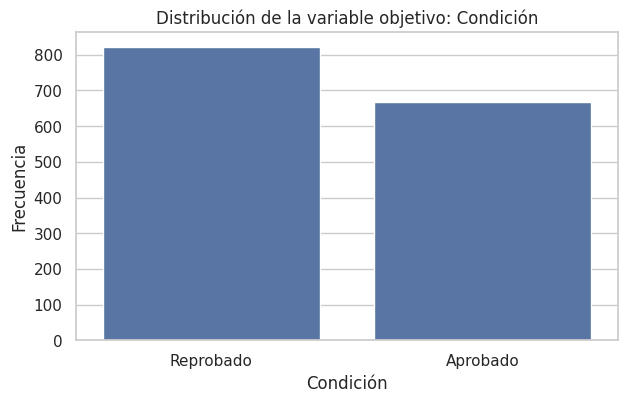

In [ ]:
# Verifica que la variable Condición exista en el dataset
if "Condición" in eda.columns:
    conteo_condicion = eda["Condición"].value_counts(dropna=False)
    porcentaje_condicion = eda["Condición"].value_counts(
        normalize=True,
        dropna=False
    ).mul(100).round(2)

    balance = pd.DataFrame({
        "Frecuencia": conteo_condicion,
        "Porcentaje": porcentaje_condicion
    })

    # Mostrar tabla resumen
    display(balance)

    plt.figure(figsize=(7, 4))
    sns.barplot(
        x=conteo_condicion.index.astype(str),
        y=conteo_condicion.values
    )
    plt.title("Distribución de la variable objetivo: Condición")
    plt.xlabel("Condición")
    plt.ylabel("Frecuencia")
    plt.show()

    # Target binario según decisión del equipo
    eda["Target_Reprobado"] = eda["Condición"].map({
        "Reprobado": 1,
        "Aprobado": 0
    })

# Si no existe la variable Condición, mostrar mensaje
else:
    print("No se encontró la variable Condición en el dataset.")



La variable objetivo `Condición` presenta una distribución relativamente balanceada entre estudiantes aprobados y reprobados.

- Reprobados: 55.17%
- Aprobados: 44.83%

Aunque existe una ligera mayor proporción de estudiantes reprobados, el desbalance no es lo suficientemente severo como para representar un problema crítico en etapas posteriores de modelado.

Esto es favorable para algoritmos de clasificación, ya que permite entrenar modelos sin necesidad inmediata de aplicar técnicas de balanceo como oversampling o undersampling.

Además, la creación de la variable binaria `Target_Reprobado` permitirá facilitar la implementación de modelos supervisados de clasificación.

## 11. Análisis Bivariado

¿Cómo se distribuyen los datos en función de diferentes categorías?

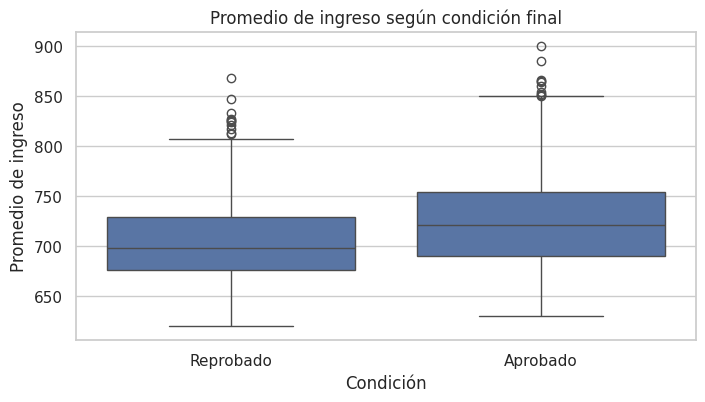


Resumen de Promedio de ingreso por condición:


,count,mean,std,min,25%,50%,75%,max
Condición,,,,,,,,
Aprobado,614.0,726.317150,48.746944,630.36,690.6375,721.35,754.605,900.00
Reprobado,727.0,705.210289,41.231892,620.19,675.9450,698.67,729.675,868.23


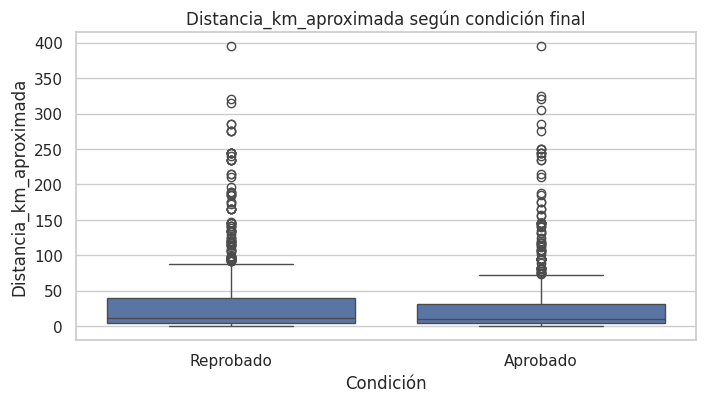


Resumen de Distancia_km_aproximada por condición:


,count,mean,std,min,25%,50%,75%,max
Condición,,,,,,,,
Aprobado,662.0,31.864350,52.202745,0.0,4.8,9.75,32.0,395.0
Reprobado,813.0,34.468635,54.198232,0.0,5.1,11.40,39.5,395.0


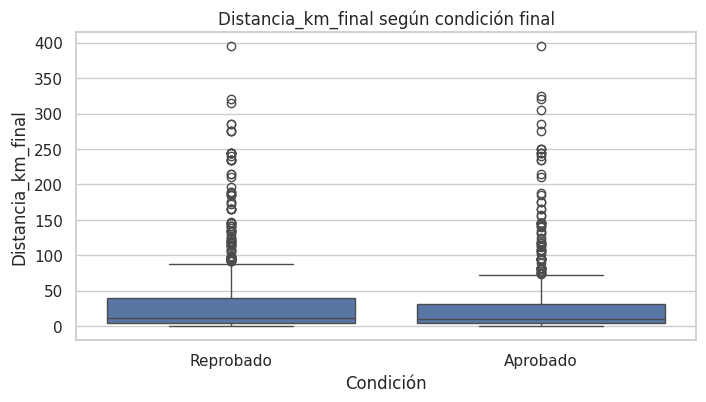


Resumen de Distancia_km_final por condición:


,count,mean,std,min,25%,50%,75%,max
Condición,,,,,,,,
Aprobado,662.0,31.864350,52.202745,0.0,4.8,9.75,32.0,395.0
Reprobado,813.0,34.468635,54.198232,0.0,5.1,11.40,39.5,395.0


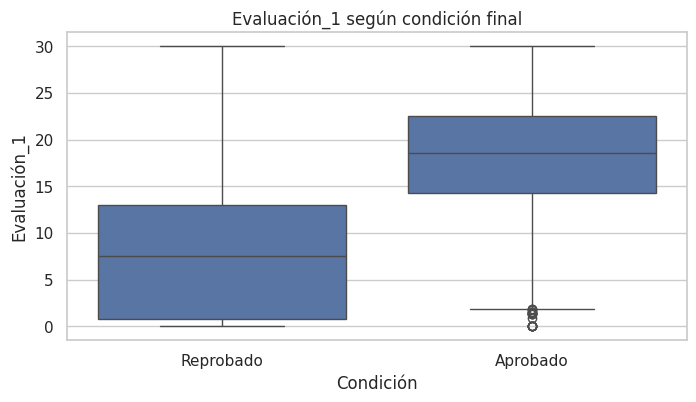


Resumen de Evaluación_1 por condición:


,count,mean,std,min,25%,50%,75%,max
Condición,,,,,,,,
Aprobado,636.0,17.873365,6.395837,0.0,14.25,18.59,22.5,30.0
Reprobado,793.0,8.194325,7.228244,0.0,0.80,7.50,13.0,30.0


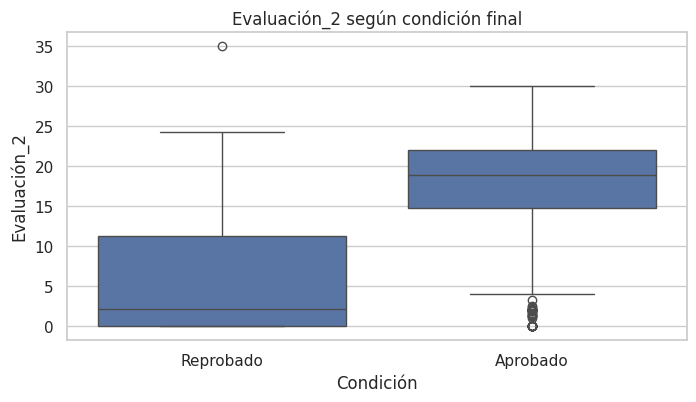


Resumen de Evaluación_2 por condición:


,count,mean,std,min,25%,50%,75%,max
Condición,,,,,,,,
Aprobado,636.0,17.562893,6.259685,0.0,14.775,18.95,22.00,30.0
Reprobado,793.0,5.689634,6.727365,0.0,0.000,2.13,11.25,35.0


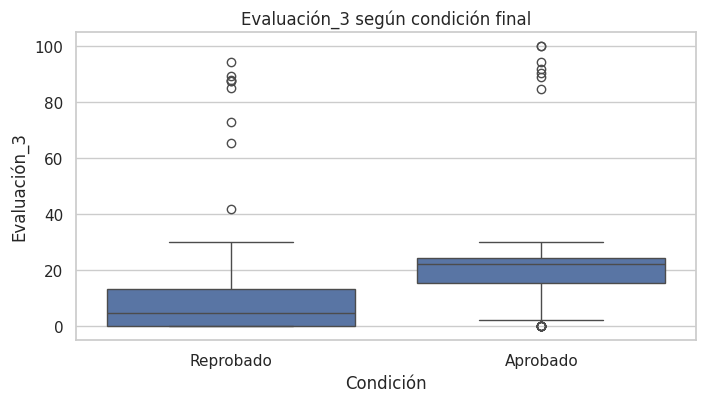


Resumen de Evaluación_3 por condición:


,count,mean,std,min,25%,50%,75%,max
Condición,,,,,,,,
Aprobado,636.0,21.258978,9.669806,0.0,15.45,22.25,24.30,100.0
Reprobado,793.0,7.856431,11.143161,0.0,0.00,4.80,13.25,94.5


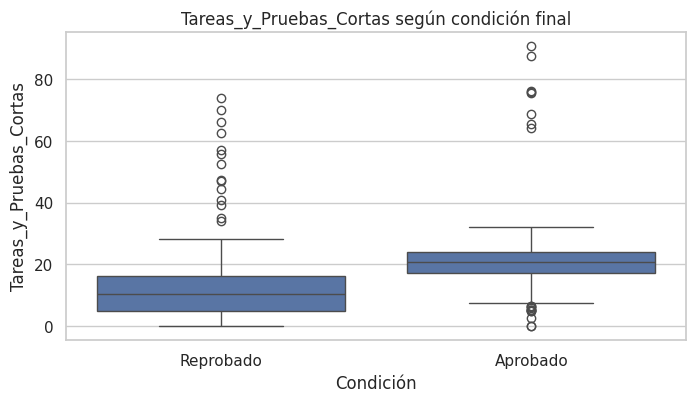


Resumen de Tareas_y_Pruebas_Cortas por condición:


,count,mean,std,min,25%,50%,75%,max
Condición,,,,,,,,
Aprobado,636.0,20.535252,7.975062,0.0,17.1625,20.775,24.00,90.67
Reprobado,792.0,11.347942,8.970682,0.0,5.0525,10.420,16.24,74.05



Distribución porcentual de Condición según Colegio de procedencia:


Condición,Aprobado,Reprobado
Colegio de procedencia,,
ACADEMIA TEOCALI,100.00,0.00
ACADÉMICO DE ORIENTACION TECNOLOGICA OMAR SALAZAR OBANDO,66.67,33.33
BACHILLERATO A DISTANCIA,30.00,70.00
BACHILLERATO POR MADUREZ,30.77,69.23
C. BILINGUE BOCA DEL MONTE,100.00,0.00
C. CIENT BIL SAGDA REINA ANGEL,0.00,100.00
C. SAN JOSE DE UPALA,100.00,0.00
C. VOCACIONAL DE HEREDIA,0.00,100.00
C.T.P BOLIVAR,0.00,100.00


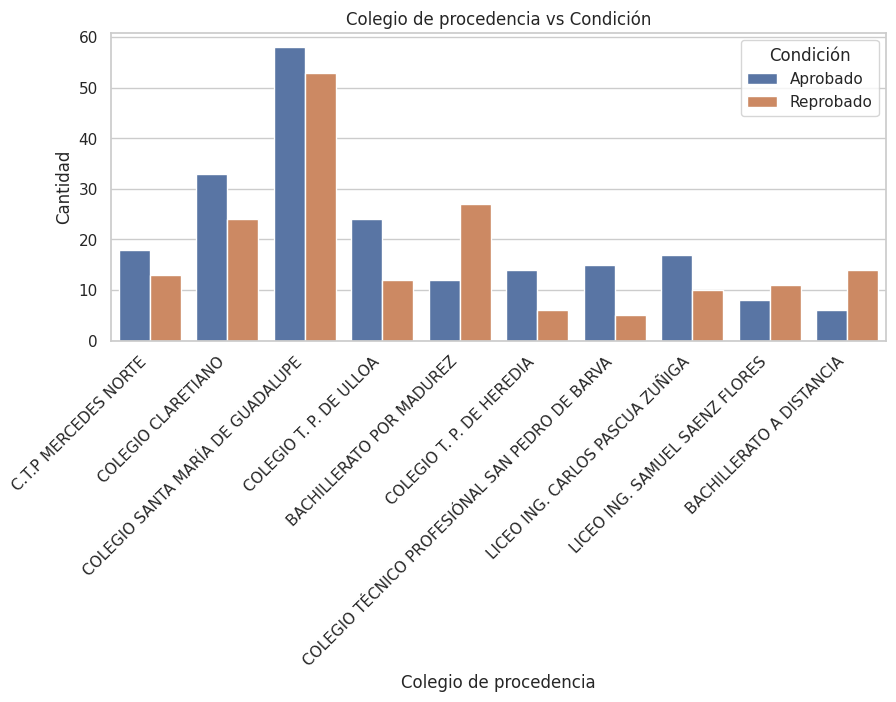


Distribución porcentual de Condición según Sexo:


Condición,Aprobado,Reprobado
Sexo,,
F,46.47,53.53
M,44.45,55.55


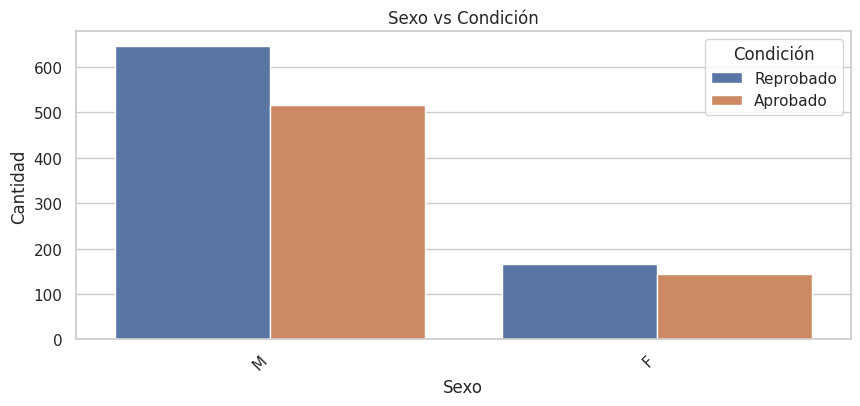

In [ ]:
# Verificar que la variable objetivo exista
if "Condición" in eda.columns:
    variables_academicas = [
        "Promedio de ingreso",
        "Distancia_km_aproximada",
        "Distancia_km_final",
        "Evaluación_1",
        "Evaluación_2",
        "Evaluación_3",
        "Tareas_y_Pruebas_Cortas"
    ]

    # Mantener únicamente las columnas que realmente existan en el dataset
    variables_academicas = [col for col in variables_academicas if col in eda.columns]

    # Boxplots por condición
    for col in variables_academicas:
        plt.figure(figsize=(8, 4))
        sns.boxplot(data=eda, x="Condición", y=col)
        plt.title(f"{col} según condición final")
        plt.xlabel("Condición")
        plt.ylabel(col)
        plt.show()

        # Resumen estadístico por condición
        print(f"\nResumen de {col} por condición:")
        display(eda.groupby("Condición")[col].describe())

# Variables categóricas vs condición
if "Condición" in eda.columns:

    # Excluir la propia variable objetivo del análisis
    categoricas_para_cruce = [c for c in cat_cols if c != "Condición"]

    # Análisis de variables categóricas
    for col in categoricas_para_cruce:

        # Tabla cruzada porcentual
        tabla = pd.crosstab(
            eda[col],
            eda["Condición"],
            normalize="index"
        ).mul(100).round(2)

        print(f"\nDistribución porcentual de Condición según {col}:")

        # Muestara únicamente las primeras 20 categorías
        display(tabla.head(20))

        # Filtra las categorías más frecuentas
        conteo = eda[col].value_counts().head(10).index
        temp = eda[eda[col].isin(conteo)]

        # Gráficos por condición
        plt.figure(figsize=(10, 4))
        sns.countplot(data=temp, x=col, hue="Condición")
        plt.title(f"{col} vs Condición")
        plt.xlabel(col)
        plt.ylabel("Cantidad")
        plt.xticks(rotation=45, ha="right")
        plt.legend(title="Condición")
        plt.show()

## Interpretación general del análisis bivariado

El análisis bivariado permitió comparar la distribución de distintas variables académicas y demográficas según la condición final del estudiante (Aprobado/Reprobado).

En general, las variables académicas muestran diferencias claras entre ambos grupos, mientras que variables demográficas como sexo y distancia presentan menor capacidad discriminatoria.

---

### Interpretación: Promedio de ingreso

Los estudiantes aprobados presentan, en promedio, valores ligeramente más altos en el promedio de ingreso respecto a los estudiantes reprobados.

Aunque existe superposición entre ambos grupos, se observa una tendencia positiva moderada entre el desempeño previo y la condición final del estudiante.

Esto sugiere que el promedio de ingreso podría tener capacidad predictiva parcial sobre el rendimiento académico posterior.

---

### Interpretación: Distancia al centro educativo

Las distribuciones de distancia son muy similares entre estudiantes aprobados y reprobados.

Aunque existen numerosos valores atípicos correspondientes a estudiantes que viven lejos del centro educativo, no se identifica una separación clara entre ambos grupos.

Esto sugiere que la distancia al centro educativo tiene una influencia limitada sobre la condición final del estudiante.

---

### Interpretación: Evaluación_1

La Evaluación_1 muestra diferencias importantes entre aprobados y reprobados.

Los estudiantes aprobados presentan medianas y rangos intercuartílicos considerablemente más altos, mientras que los reprobados concentran gran parte de sus valores en rangos bajos.

Esto indica que el desempeño inicial del estudiante tiene una relación importante con la condición final.

---

### Interpretación: Evaluación_2

La Evaluación_2 presenta una separación aún más marcada entre estudiantes aprobados y reprobados.

Los estudiantes aprobados se concentran principalmente en valores medios y altos, mientras que los reprobados muestran una acumulación importante de notas bajas e incluso valores cercanos a cero.

Esto sugiere que esta variable podría ser una de las más relevantes para predecir la condición final.

---

### Interpretación: Evaluación_3

La Evaluación_3 muestra una clara diferencia entre aprobados y reprobados.

Los estudiantes aprobados presentan valores consistentemente más altos y menor concentración en notas bajas.

También se observan valores atípicos extremos en ambos grupos, posiblemente asociados a evaluaciones extraordinarias o escalas distintas.

Esta variable parece tener una alta capacidad discriminatoria respecto a la condición final.

---

### Interpretación: Tareas y pruebas cortas

Los estudiantes aprobados presentan valores significativamente superiores en tareas y pruebas cortas respecto a los reprobados.

Esto sugiere que el desempeño continuo durante el curso tiene una relación importante con el resultado final del estudiante.

Además, se identifican algunos valores atípicos altos en ambos grupos.

---

### Interpretación: Colegio de procedencia

Se observan diferencias importantes en los porcentajes de aprobación y reprobación entre algunos colegios de procedencia.

Sin embargo, varios colegios presentan pocos registros, por lo que estos resultados deben interpretarse con cautela y no necesariamente implican una relación causal directa.

Debido a su alta cardinalidad, esta variable podría requerir técnicas especiales de codificación en etapas posteriores de modelado.

---

### Interpretación: Sexo

La distribución porcentual de aprobados y reprobados es relativamente similar entre hombres y mujeres.

Esto sugiere que el sexo no presenta una relación fuerte con la condición final del estudiante dentro de este conjunto de datos.

## 12. Análisis multivariado (correlaciones)

¿Hay correlación entre las variables dependientes e independientes?

,Año_lectivo,Promedio de ingreso,Distancia_km_aproximada,Grupo,Evaluación_1,Evaluación_2,Evaluación_3,Tareas_y_Pruebas_Cortas,Nota_Final,Nota_Final_Redondeo,Distancia_km_final,Distancia_missing,Target_Reprobado
Año_lectivo,1.000000,-0.210299,0.024848,0.066968,-0.262872,0.042033,-0.154187,-0.264637,-0.291378,-0.135751,0.024848,0.019931,0.168785
Promedio de ingreso,-0.210299,1.000000,-0.025192,0.063793,0.183502,0.136925,0.179080,0.171822,0.281618,0.248988,-0.025192,NaN,-0.228540
Distancia_km_aproximada,0.024848,-0.025192,1.000000,0.017057,-0.014621,0.006890,-0.035797,-0.034741,-0.009434,-0.019171,1.000000,NaN,0.024306
Grupo,0.066968,0.063793,0.017057,1.000000,0.047304,0.095988,-0.077865,-0.047963,0.103054,0.074108,0.017057,0.038197,-0.042158
Evaluación_1,-0.262872,0.183502,-0.014621,0.047304,1.000000,0.617889,0.498021,0.499402,0.731108,0.777645,-0.014621,-0.027351,-0.573813
Evaluación_2,0.042033,0.136925,0.006890,0.095988,0.617889,1.000000,0.536005,0.557628,0.715276,0.823459,0.006890,-0.023240,-0.671082
Evaluación_3,-0.154187,0.179080,-0.035797,-0.077865,0.498021,0.536005,1.000000,0.721474,0.653238,0.691303,-0.035797,-0.034909,-0.535459
Tareas_y_Pruebas_Cortas,-0.264637,0.171822,-0.034741,-0.047963,0.499402,0.557628,0.721474,1.000000,0.663520,0.665196,-0.034741,-0.044388,-0.471697
Nota_Final,-0.291378,0.281618,-0.009434,0.103054,0.731108,0.715276,0.653238,0.663520,1.000000,0.895282,-0.009434,-0.027094,-0.712570
Nota_Final_Redondeo,-0.135751,0.248988,-0.019171,0.074108,0.777645,0.823459,0.691303,0.665196,0.895282,1.000000,-0.019171,-0.044091,-0.778663


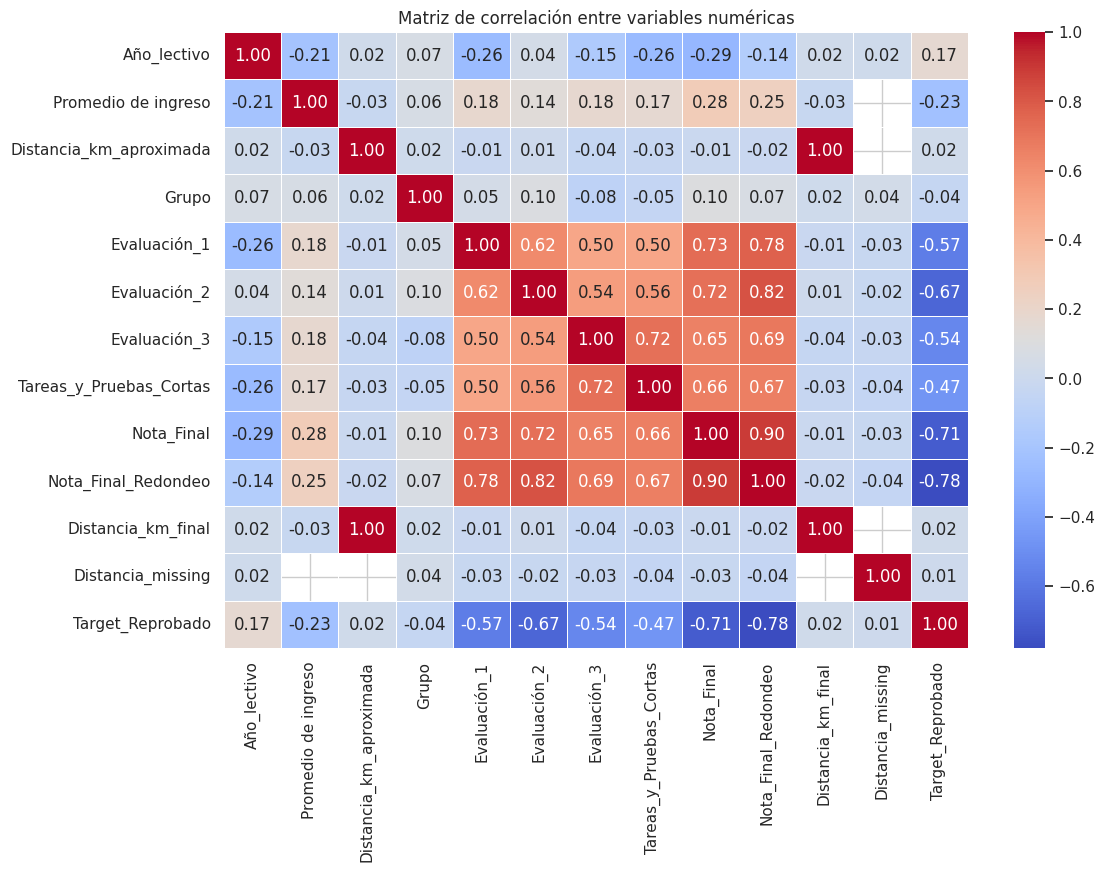

,Correlación con Target_Reprobado
Target_Reprobado,1.000000
Año_lectivo,0.168785
Distancia_km_aproximada,0.024306
Distancia_km_final,0.024306
Distancia_missing,0.009798
Grupo,-0.042158
Promedio de ingreso,-0.228540
Tareas_y_Pruebas_Cortas,-0.471697
Evaluación_3,-0.535459
Evaluación_1,-0.573813


In [ ]:
num_cols_corr = eda.select_dtypes(include=[np.number]).columns.tolist()
num_cols_corr = [col for col in num_cols_corr if col != "ID"]

# Cálculo de la matriz de correlación
correlaciones = eda[num_cols_corr].corr(numeric_only=True)

# Muestra la matriz de correlación en formato tabular
display(correlaciones)

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlaciones,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

# Correlación con la variable objetivo
if "Target_Reprobado" in correlaciones.columns:
    corr_target = correlaciones["Target_Reprobado"].sort_values(
        ascending=False
    ).to_frame("Correlación con Target_Reprobado")

    # Muestra correlaciones ordenadas
    display(corr_target)

## Interpretación general del análisis multivariado

El análisis multivariado mediante correlaciones permitió identificar la intensidad y dirección de la relación lineal entre las variables numéricas del conjunto de datos y la variable objetivo `Target_Reprobado`.

En general, las variables académicas muestran correlaciones fuertes entre sí y una relación importante con la condición final del estudiante, mientras que las variables demográficas presentan correlaciones débiles.

---

## Interpretación de la matriz de correlación

La matriz de correlación evidencia varios patrones importantes:

- Las evaluaciones parciales (`Evaluación_1`, `Evaluación_2`, `Evaluación_3`) presentan correlaciones positivas moderadas y fuertes entre sí.
- `Nota_Final` y `Nota_Final_Redondeo` muestran correlaciones muy altas con las evaluaciones académicas.
- Las variables relacionadas con distancia (`Distancia_km_aproximada` y `Distancia_km_final`) prácticamente no presentan relación con el desempeño académico.
- El `Promedio de ingreso` tiene correlaciones positivas moderadas con las notas finales y evaluaciones.

Esto sugiere que el rendimiento académico interno del curso es el principal factor asociado con la condición final del estudiante.

---

## Variables con mayor correlación positiva

Las correlaciones positivas más altas observadas fueron:

- `Nota_Final` ↔ `Nota_Final_Redondeo` → correlación extremadamente alta (~0.90)
- `Evaluación_2` ↔ `Nota_Final_Redondeo` → correlación fuerte (~0.82)
- `Evaluación_1` ↔ `Nota_Final_Redondeo` → correlación fuerte (~0.78)
- `Evaluación_3` ↔ `Tareas_y_Pruebas_Cortas` → correlación fuerte (~0.72)

Estas relaciones son esperadas debido a que varias de estas variables participan directa o indirectamente en el cálculo de la nota final.

---

## Correlación con la variable objetivo: `Target_Reprobado`

La variable objetivo `Target_Reprobado` presenta correlaciones negativas importantes con las variables académicas, lo cual indica que mayores calificaciones se asocian con una menor probabilidad de reprobar.

Las variables más relevantes fueron:

| Variable | Correlación con Target_Reprobado |
|---|---|
| Nota_Final_Redondeo | -0.78 |
| Nota_Final | -0.71 |
| Evaluación_2 | -0.67 |
| Evaluación_1 | -0.57 |
| Evaluación_3 | -0.54 |
| Tareas_y_Pruebas_Cortas | -0.47 |

Esto indica que las evaluaciones y actividades académicas son los principales factores predictivos de reprobación.

---

## Variables con baja correlación

Algunas variables presentan correlaciones muy bajas o cercanas a cero respecto a la variable objetivo:

- `Distancia_km_aproximada`
- `Distancia_km_final`
- `Grupo`
- `Distancia_missing`

Esto sugiere que estas variables tienen poca capacidad explicativa sobre la condición final del estudiante.

---

## Interpretación del Promedio de ingreso

El `Promedio de ingreso` presenta una correlación negativa moderada con `Target_Reprobado` (~ -0.23).

Esto indica que estudiantes con mejores promedios de ingreso tienden ligeramente a reprobar menos, aunque la relación no es tan fuerte como la observada con las evaluaciones del curso.

---

## Posible multicolinealidad

Se identifican correlaciones altas entre varias variables académicas:

- `Evaluación_1`, `Evaluación_2`, `Evaluación_3`
- `Nota_Final`
- `Nota_Final_Redondeo`

Esto puede indicar presencia de multicolinealidad, especialmente en modelos lineales.

En etapas posteriores de modelado podría ser recomendable:

- eliminar variables redundantes,
- aplicar regularización,
- o utilizar modelos menos sensibles a multicolinealidad.

---

## Conclusión general

El análisis multivariado confirma que:

- Las variables académicas son los principales factores asociados al rendimiento final.
- Las notas parciales y actividades tienen alta capacidad predictiva sobre la reprobación.
- Variables demográficas y de distancia tienen poca relación con la condición final.
- Existe una fuerte relación entre las diferentes evaluaciones académicas y la nota final.
- Puede existir multicolinealidad entre variables derivadas de desempeño académico.

## 13. Tendencias temporales

¿Se identifican tendencias temporales?

,Cantidad de registros
Año_lectivo,
2020,224
2021,238
2022,278
2023,215
2024,249
2025,286


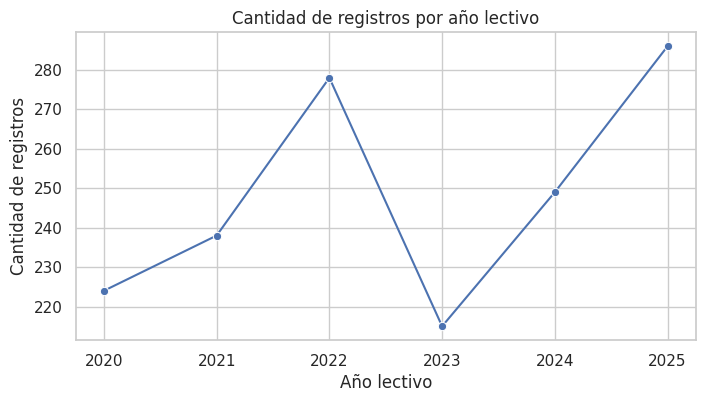

Condición,Aprobado,Reprobado
Año_lectivo,,
2020,50.89,49.11
2021,59.24,40.76
2022,44.96,55.04
2023,48.84,51.16
2024,41.37,58.63
2025,27.97,72.03


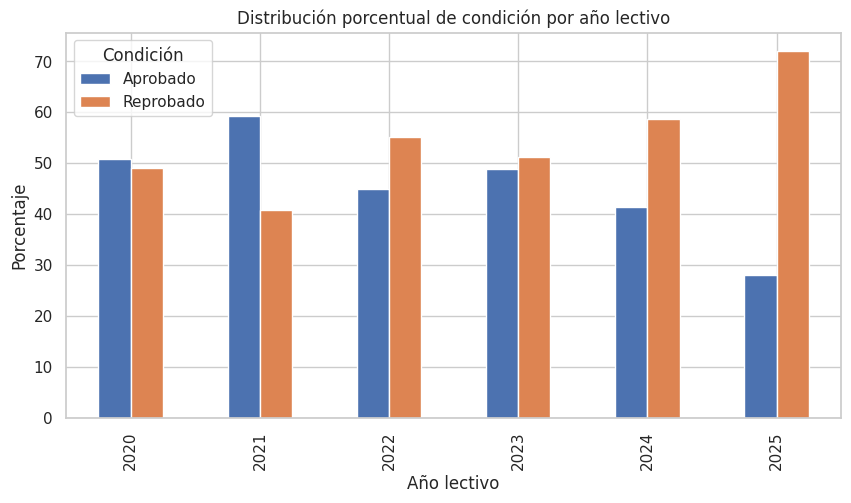

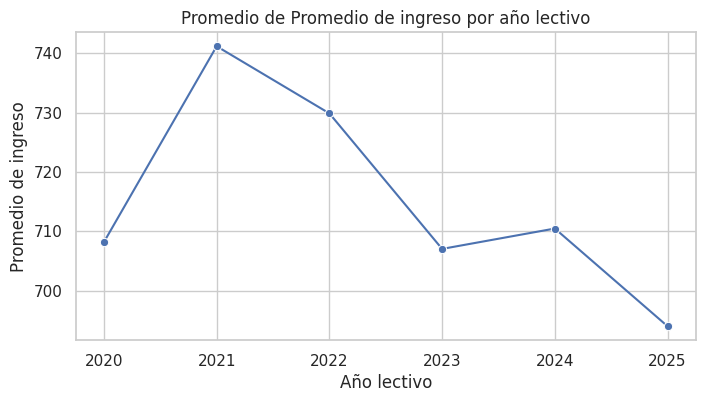

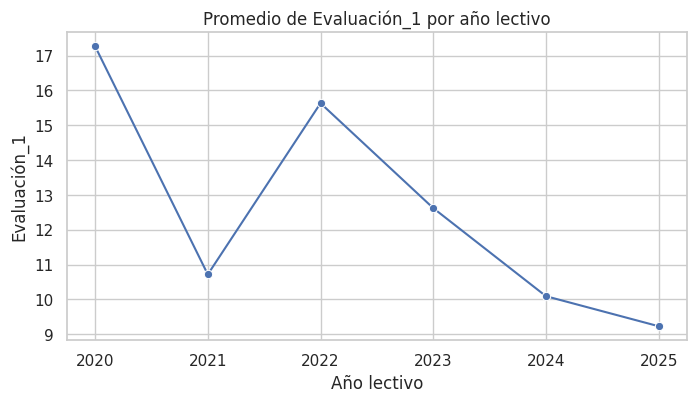

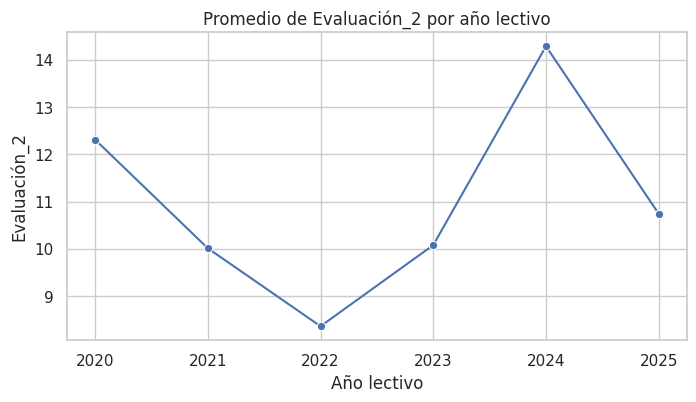

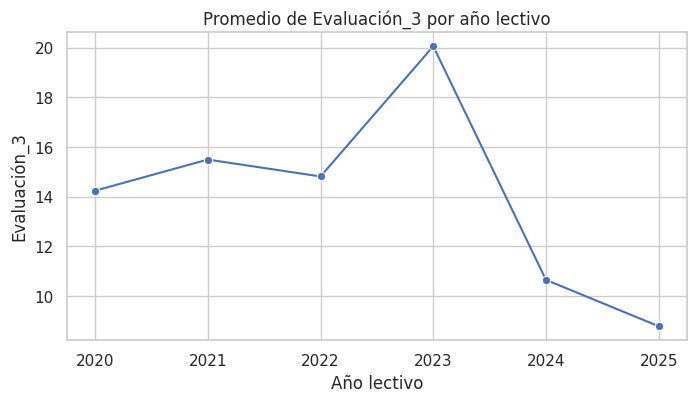

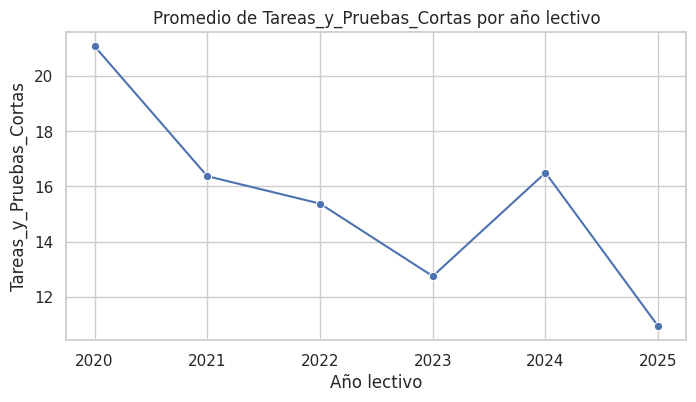

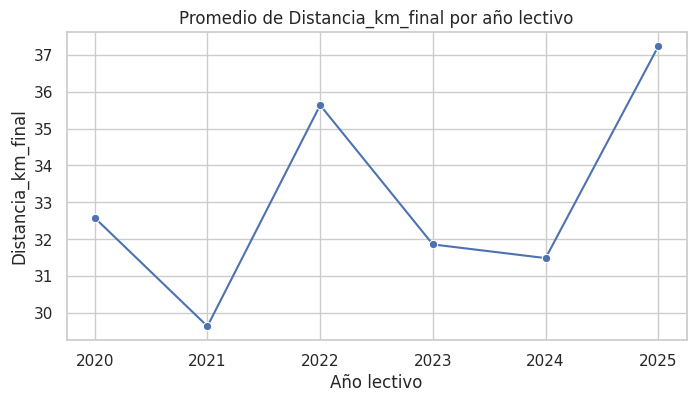

In [ ]:
# Verifica si existe la variable temporal Año_lectivo

# Se calcula la cantidad de estudiantes registrados en cada año lectivo.
if "Año_lectivo" in eda.columns:

    # Cantidad de registros por año
    registros_por_anio = eda["Año_lectivo"].value_counts().sort_index()

    # Muestra la tabla de registros por año
    display(registros_por_anio.to_frame("Cantidad de registros"))

    # Gráfico de registros por año
    plt.figure(figsize=(8, 4))
    sns.lineplot(
        x=registros_por_anio.index,
        y=registros_por_anio.values,
        marker="o"
    )
    plt.title("Cantidad de registros por año lectivo")
    plt.xlabel("Año lectivo")
    plt.ylabel("Cantidad de registros")
    plt.show()

    # Distribución de aprobados y reprobados por año
    if "Condición" in eda.columns:
        tabla_anio_condicion = pd.crosstab(
            eda["Año_lectivo"],
            eda["Condición"],
            normalize="index"
        ).mul(100).round(2)

        # Muestra la tabla porcentual
        display(tabla_anio_condicion)

        # Gráfico de distribución por año
        tabla_anio_condicion.plot(kind="bar", figsize=(10, 5))
        plt.title("Distribución porcentual de condición por año lectivo")
        plt.xlabel("Año lectivo")
        plt.ylabel("Porcentaje")
        plt.legend(title="Condición")
        plt.show()

    # Tendencia de variables académicas por año
    variables_tendencia = [
        "Promedio de ingreso",
        "Evaluación_1",
        "Evaluación_2",
        "Evaluación_3",
        "Tareas_y_Pruebas_Cortas",
        "Distancia_km_final"
    ]

    # Mantiene únicamente variables existentes
    variables_tendencia = [col for col in variables_tendencia if col in eda.columns]

    # Gráficos de tendencia
    for col in variables_tendencia:
        plt.figure(figsize=(8, 4))
        sns.lineplot(
            data=eda,
            x="Año_lectivo",
            y=col,
            estimator="mean",
            errorbar=None,
            marker="o"
        )
        plt.title(f"Promedio de {col} por año lectivo")
        plt.xlabel("Año lectivo")
        plt.ylabel(col)
        plt.show()

# Si no existe Año_lectivo, mostrar mensaje
else:
    print("No se encontró Año_lectivo en el dataset.")

## Interpretación general de las tendencias temporales

El análisis temporal permitió evaluar cómo han cambiado los registros académicos y la condición final de los estudiantes a lo largo de los años lectivos entre 2020 y 2025.

Se identifican variaciones importantes tanto en la cantidad de estudiantes registrados como en el comportamiento académico y las tasas de aprobación/reprobación.

---

## Evolución de la cantidad de registros por año

La cantidad de estudiantes registrados presenta fluctuaciones moderadas durante el período analizado:

| Año | Registros |
|---|---|
| 2020 | 224 |
| 2021 | 238 |
| 2022 | 278 |
| 2023 | 215 |
| 2024 | 249 |
| 2025 | 286 |

### Observaciones:

- El año 2025 presenta la mayor cantidad de registros.
- En 2023 se observa una disminución importante en el número de estudiantes.
- Existe una tendencia general de crecimiento hacia los últimos años.

Esto podría indicar una mayor cobertura institucional o un aumento en la matrícula estudiantil.

---

## Tendencia de aprobación y reprobación por año

La distribución porcentual de la condición final evidencia cambios relevantes a través del tiempo:

| Año | % Aprobado | % Reprobado |
|---|---|---|
| 2020 | 50.89 | 49.11 |
| 2021 | 59.24 | 40.76 |
| 2022 | 44.96 | 55.04 |
| 2023 | 48.84 | 51.16 |
| 2024 | 41.37 | 58.63 |
| 2025 | 27.97 | 72.03 |

### Interpretación:

- El mejor desempeño académico se presentó en 2021.
- A partir de 2022 aumenta progresivamente la tasa de reprobación.
- En 2025 se observa el peor desempeño del período, con más del 72% de estudiantes reprobados.

Esto podría estar relacionado con:

- cambios curriculares,
- variaciones en la dificultad de las evaluaciones,
- efectos postpandemia,
- diferencias en cohortes estudiantiles,
- o modificaciones institucionales.

---

## Tendencia del promedio de ingreso

El promedio de ingreso presenta una ligera disminución en los últimos años:

| Año | Promedio aproximado |
|---|---|
| 2020 | 708 |
| 2021 | 741 |
| 2022 | 730 |
| 2023 | 707 |
| 2024 | 710 |
| 2025 | 694 |

### Interpretación:

- El mejor promedio de ingreso ocurrió en 2021.
- En 2025 se registra el promedio más bajo.
- Existe una posible relación entre la disminución del promedio de ingreso y el aumento en la tasa de reprobación.

---

## Tendencia de Evaluación_1

La media de `Evaluación_1` disminuye considerablemente hacia los años más recientes:

| Año | Promedio aproximado |
|---|---|
| 2020 | 17.2 |
| 2021 | 10.7 |
| 2022 | 15.6 |
| 2023 | 12.6 |
| 2024 | 10.1 |
| 2025 | 9.2 |

### Interpretación:

- El rendimiento en esta evaluación cae notablemente en 2024 y 2025.
- Esto coincide con el incremento de reprobación observado.

---

## Tendencia de Evaluación_2

La segunda evaluación muestra un comportamiento más variable:

| Año | Promedio aproximado |
|---|---|
| 2020 | 12.3 |
| 2021 | 10.0 |
| 2022 | 8.4 |
| 2023 | 10.0 |
| 2024 | 14.3 |
| 2025 | 10.7 |

### Interpretación:

- Existe una mejora importante en 2024.
- Sin embargo, dicha mejora no fue suficiente para reducir la tasa de reprobación global.

---

## Tendencia de Evaluación_3

La tercera evaluación presenta fuertes cambios entre años:

| Año | Promedio aproximado |
|---|---|
| 2020 | 14.2 |
| 2021 | 15.5 |
| 2022 | 14.9 |
| 2023 | 20.0 |
| 2024 | 10.6 |
| 2025 | 8.8 |

### Interpretación:

- En 2023 se obtuvo el mejor rendimiento histórico.
- Posteriormente ocurre una caída abrupta en 2024 y 2025.
- Este comportamiento parece estar altamente relacionado con el incremento de reprobaciones.

---

## Tendencia de Tareas y Pruebas Cortas

La variable `Tareas_y_Pruebas_Cortas` muestra una tendencia descendente:

| Año | Promedio aproximado |
|---|---|
| 2020 | 21.0 |
| 2021 | 16.3 |
| 2022 | 15.4 |
| 2023 | 12.7 |
| 2024 | 16.5 |
| 2025 | 10.9 |

### Interpretación:

- Existe una reducción general del desempeño continuo.
- 2025 registra el valor más bajo del período.

---

## Tendencia de Distancia_km_final

La distancia promedio no presenta un patrón claramente asociado al rendimiento académico:

| Año | Distancia promedio |
|---|---|
| 2020 | 32.6 |
| 2021 | 29.6 |
| 2022 | 35.6 |
| 2023 | 31.8 |
| 2024 | 31.5 |
| 2025 | 37.2 |

### Interpretación:

- Aunque existen fluctuaciones, no se observa una relación clara entre distancia y condición final.
- Esto coincide con los resultados del análisis de correlación.

---

## Conclusión general

El análisis temporal evidencia que:

- La tasa de reprobación ha aumentado considerablemente en los años más recientes.
- Las variables académicas muestran una tendencia descendente en desempeño, especialmente en 2024 y 2025.
- El promedio de ingreso también disminuye ligeramente en los últimos años.
- Las evaluaciones y actividades académicas parecen explicar gran parte del deterioro en la condición final.
- La distancia geográfica no parece influir significativamente en el rendimiento académico.

En conjunto, los resultados sugieren un deterioro progresivo del desempeño estudiantil hacia los últimos años lectivos.

## 14. Validación de hipótesis del equipo 28

,Cantidad de registros
Año_lectivo,
2020,224
2021,238
2022,278
2023,215
2024,249
2025,286


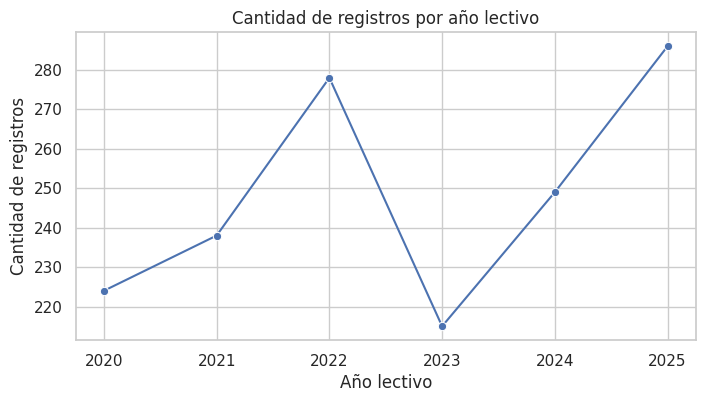

Condición,Aprobado,Reprobado
Año_lectivo,,
2020,50.89,49.11
2021,59.24,40.76
2022,44.96,55.04
2023,48.84,51.16
2024,41.37,58.63
2025,27.97,72.03


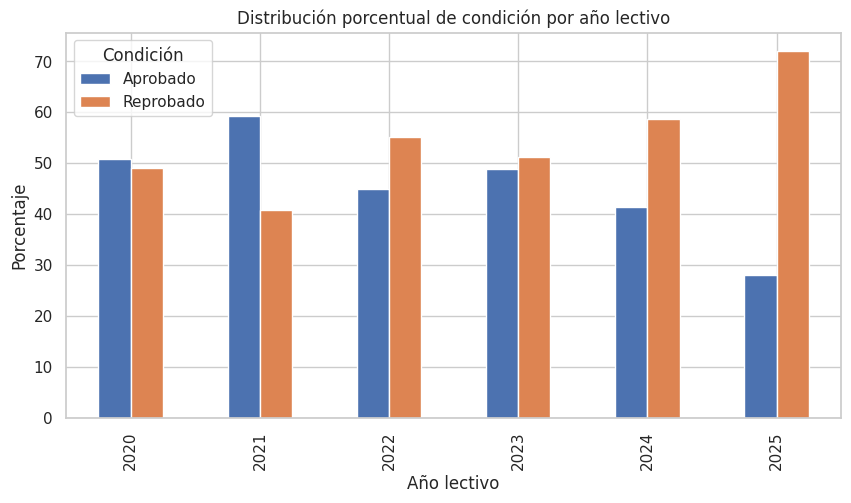

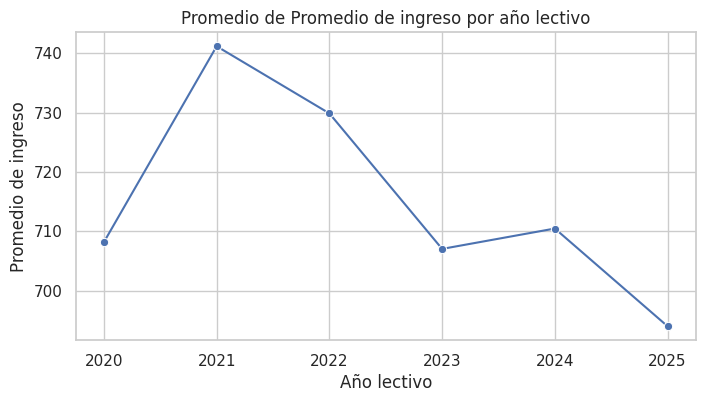

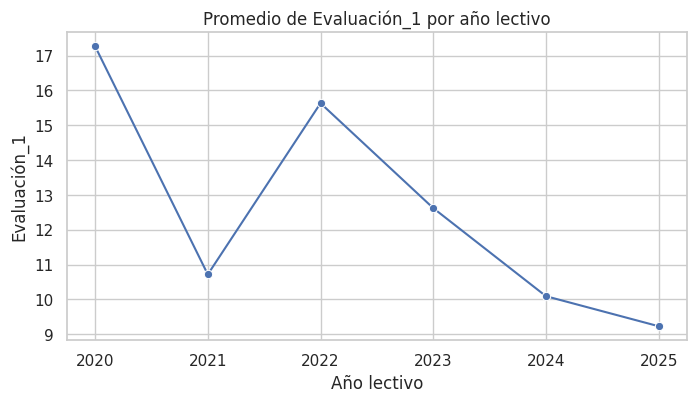

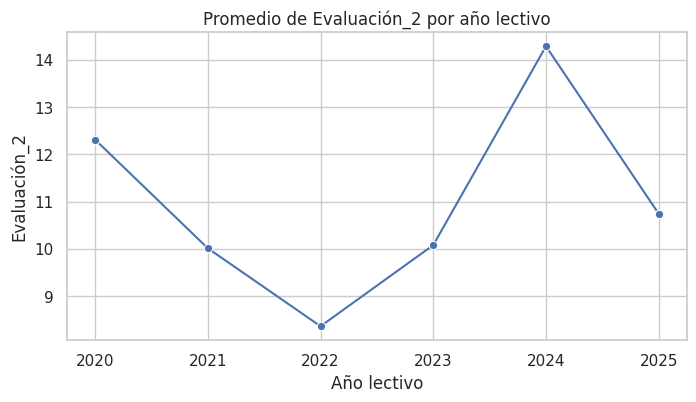

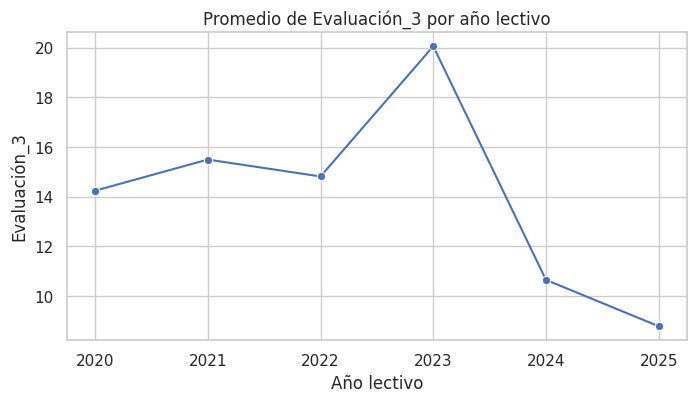

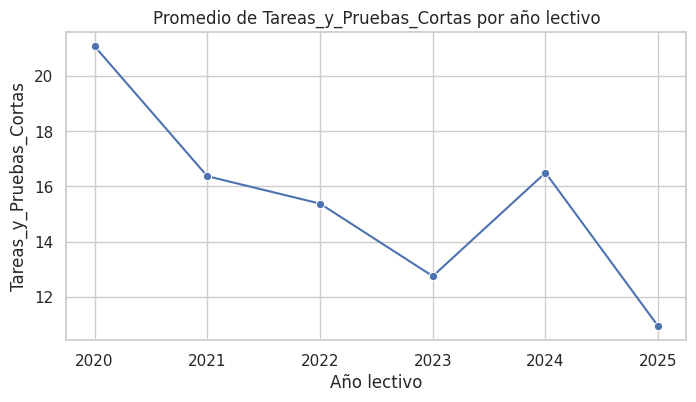

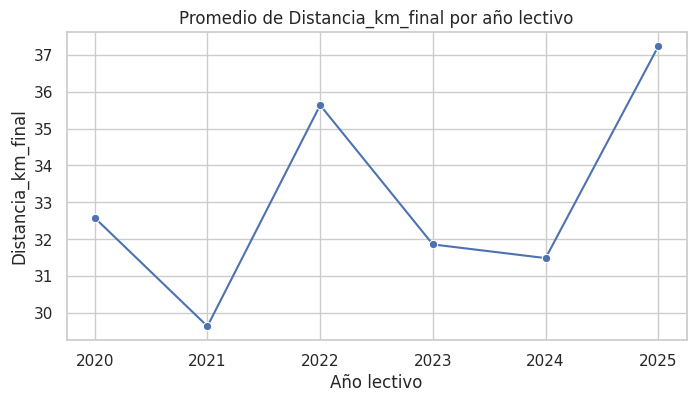

In [ ]:
# Verificar si la variable Año_lectivo existe
if "Año_lectivo" in eda.columns:
    registros_por_anio = eda["Año_lectivo"].value_counts().sort_index()

    # Muestra la tabla resumen
    display(registros_por_anio.to_frame("Cantidad de registros"))

    # Gráfico de registros por año
    plt.figure(figsize=(8, 4))
    sns.lineplot(
        x=registros_por_anio.index,
        y=registros_por_anio.values,
        marker="o"
    )
    plt.title("Cantidad de registros por año lectivo")
    plt.xlabel("Año lectivo")
    plt.ylabel("Cantidad de registros")
    plt.show()

    # Distribución de condición por año
    if "Condición" in eda.columns:
        tabla_anio_condicion = pd.crosstab(
            eda["Año_lectivo"],
            eda["Condición"],
            normalize="index"
        ).mul(100).round(2)

        # Muestra la tabla resumen
        display(tabla_anio_condicion)

        # Gráfico de distribución por año
        tabla_anio_condicion.plot(kind="bar", figsize=(10, 5))
        plt.title("Distribución porcentual de condición por año lectivo")
        plt.xlabel("Año lectivo")
        plt.ylabel("Porcentaje")
        plt.legend(title="Condición")
        plt.show()

    # Tendencia de variables académicas por año
    variables_tendencia = [
        "Promedio de ingreso",
        "Evaluación_1",
        "Evaluación_2",
        "Evaluación_3",
        "Tareas_y_Pruebas_Cortas",
        "Distancia_km_final"
    ]

    # Mantiene únicamente variables existentes en el dataset
    variables_tendencia = [col for col in variables_tendencia if col in eda.columns]

    # Gráfico de tendencia de variables académicas
    for col in variables_tendencia:
        plt.figure(figsize=(8, 4))
        sns.lineplot(
            data=eda,
            x="Año_lectivo",
            y=col,
            estimator="mean",
            errorbar=None,
            marker="o"
        )
        plt.title(f"Promedio de {col} por año lectivo")
        plt.xlabel("Año lectivo")
        plt.ylabel(col)
        plt.show()
else:
    print("No se encontró Año_lectivo en el dataset.")



Con base en el análisis temporal realizado sobre el conjunto de datos, se evaluaron distintas hipótesis relacionadas con el comportamiento académico de los estudiantes a lo largo de los años lectivos.

---

## Hipótesis 1: El porcentaje de reprobación ha aumentado en los últimos años

### Resultado: Validada

La distribución porcentual de la variable objetivo (`Condición`) muestra un incremento progresivo en la tasa de reprobación:

| Año | % Reprobado |
|---|---|
| 2020 | 49.11% |
| 2021 | 40.76% |
| 2022 | 55.04% |
| 2023 | 51.16% |
| 2024 | 58.63% |
| 2025 | 72.03% |

### Interpretación:

- El año 2021 presentó el menor porcentaje de reprobación.
- A partir de 2022 comienza una tendencia creciente.
- En 2025 se alcanza el valor más alto de reprobación del período.

Esto evidencia un deterioro progresivo del rendimiento académico estudiantil.

---

## Hipótesis 2: El rendimiento académico ha disminuido con el tiempo

### Resultado: Parcialmente validada

Las variables académicas muestran una disminución importante en los años recientes.

### Evaluación_1

| Año | Promedio |
|---|---|
| 2020 | 17.2 |
| 2025 | 9.2 |

### Evaluación_3

| Año | Promedio |
|---|---|
| 2023 | 20.0 |
| 2025 | 8.8 |

### Tareas y Pruebas Cortas

| Año | Promedio |
|---|---|
| 2020 | 21.0 |
| 2025 | 10.9 |

### Interpretación:

- Se observa una caída significativa en varias evaluaciones.
- El descenso coincide con el incremento de reprobación.
- Aunque algunas variables presentan fluctuaciones intermedias, la tendencia global es negativa.

---

## Hipótesis 3: El promedio de ingreso influye en el desempeño académico

### Resultado: Validada moderadamente

El promedio de ingreso presenta una reducción gradual en los últimos años:

| Año | Promedio de ingreso |
|---|---|
| 2021 | 741 |
| 2025 | 694 |

Además, en el análisis de correlación se observó:

- Correlación negativa con `Target_Reprobado`: **-0.23**

### Interpretación:

- Los estudiantes con mayor promedio de ingreso tienden a reprobar menos.
- Sin embargo, la relación no es extremadamente fuerte.
- Esto indica que el promedio de ingreso sí influye, pero no explica por sí solo el rendimiento final.

---

## Hipótesis 4: Las evaluaciones tienen alta influencia sobre la condición final

### Resultado: Fuertemente validada

Las correlaciones más altas con `Target_Reprobado` corresponden a variables académicas:

| Variable | Correlación |
|---|---|
| Nota_Final_Redondeo | -0.78 |
| Nota_Final | -0.71 |
| Evaluación_2 | -0.67 |
| Evaluación_1 | -0.57 |
| Evaluación_3 | -0.54 |
| Tareas_y_Pruebas_Cortas | -0.47 |

### Interpretación:

- Existe una fuerte relación inversa entre las calificaciones y la reprobación.
- A mejores evaluaciones, menor probabilidad de reprobar.
- Las evaluaciones representan los factores más importantes del modelo académico.

---

## Hipótesis 5: La distancia del estudiante afecta el rendimiento académico

### Resultado: No validada

Las variables relacionadas con distancia presentan correlaciones prácticamente nulas:

| Variable | Correlación con reprobación |
|---|---|
| Distancia_km_aproximada | 0.02 |
| Distancia_km_final | 0.02 |

### Interpretación:

- No existe evidencia estadística de que la distancia influya significativamente en la condición final.
- Aunque existen estudiantes con distancias muy altas, esto no se traduce directamente en mayor reprobación.

---

## Hipótesis 6: El desempeño académico reciente muestra deterioro institucional

### Resultado: Posiblemente validada

Los años más recientes presentan simultáneamente:

- mayores porcentajes de reprobación,
- menores promedios académicos,
- reducción en tareas y evaluaciones,
- y menor promedio de ingreso.

### Interpretación:

Esto podría indicar:

- cambios institucionales,
- diferencias entre cohortes,
- efectos postpandemia,
- modificaciones curriculares,
- o factores externos que afectaron el desempeño estudiantil.

Sin embargo, sería necesario realizar análisis adicionales para confirmar las causas exactas.

---

## Conclusión general

La validación de hipótesis permitió confirmar que:

- El rendimiento académico se ha deteriorado en los años recientes.
- Las evaluaciones y notas finales son los principales factores asociados con la reprobación.
- El promedio de ingreso tiene influencia moderada.
- La distancia geográfica no presenta impacto significativo.
- El año 2025 representa el período con peores indicadores académicos del conjunto analizado.

En general, los resultados sugieren que el fenómeno de reprobación está principalmente asociado al desempeño académico interno y no a factores geográficos.

## 15. Preprocesamiento propuesto y justificado luego del análisis exploratorio de datos

In [ ]:
pre = eda.copy()

# Crear variable objetivo binaria
if "Condición" in pre.columns:
    pre["Target_Reprobado"] = pre["Condición"].map({
        "Reprobado": 1,
        "Aprobado": 0
    })

# Columnas a eliminar según decisiones del equipo
columnas_eliminar = [
    "ID",
    "Nota_Final",
    "Nota_Final_Redondeo",
    "Condición"
]

# Si existe distancia final, se elimina colegio para reducir alta cardinalidad
if "Distancia_km_final" in pre.columns:
    columnas_eliminar.append("Colegio de procedencia")

# Si existe distancia original y distancia final, se elimina la original
if "Distancia_km_aproximada" in pre.columns and "Distancia_km_final" in pre.columns:
    columnas_eliminar.append("Distancia_km_aproximada")

columnas_eliminar = [col for col in columnas_eliminar if col in pre.columns]

pre = pre.drop(columns=columnas_eliminar)

print("Columnas eliminadas:")
print(columnas_eliminar)

# Imputación numérica con mediana
num_features = pre.select_dtypes(include=[np.number]).columns.tolist()

if "Target_Reprobado" in num_features:
    num_features.remove("Target_Reprobado")

for col in num_features:
    pre[col] = pre[col].fillna(pre[col].median())

# Imputación categórica con Desconocido
cat_features = pre.select_dtypes(include=["object"]).columns.tolist()

for col in cat_features:
    pre[col] = pre[col].fillna("Desconocido")

# Grupo como categórica nominal
if "Grupo" in pre.columns:
    pre["Grupo"] = pre["Grupo"].astype(str)

# Reduce la alta cardinalidad si queda alguna variable categórica grande
cat_features = pre.select_dtypes(include=["object"]).columns.tolist()

for col in cat_features:
    if pre[col].nunique() > 20:
        categorias_frecuentes = pre[col].value_counts().head(20).index
        pre[col] = np.where(
            pre[col].isin(categorias_frecuentes),
            pre[col],
            "Otros"
        )

print("Valores faltantes después de imputación:")
display(pre.isna().sum().to_frame("Valores faltantes"))

print("Dataset previo a encoding:")
display(pre.head())

Columnas eliminadas:
['ID', 'Nota_Final', 'Nota_Final_Redondeo', 'Condición', 'Colegio de procedencia', 'Distancia_km_aproximada']
Valores faltantes después de imputación:


,Valores faltantes
Año_lectivo,0
Promedio de ingreso,0
Sexo,0
Grupo,0
Evaluación_1,0
Evaluación_2,0
Evaluación_3,0
Tareas_y_Pruebas_Cortas,0
Distancia_km_final,0
Distancia_missing,0


Dataset previo a encoding:


,Año_lectivo,Promedio de ingreso,Sexo,Grupo,Evaluación_1,Evaluación_2,Evaluación_3,Tareas_y_Pruebas_Cortas,Distancia_km_final,Distancia_missing,Target_Reprobado
0,2020,708.48,M,1,0.0,0.00,0.0,47.43,18.0,0,1
1,2020,717.21,M,1,26.7,19.50,28.5,75.87,6.0,0,0
2,2020,702.27,M,1,16.5,15.60,88.0,52.56,69.0,0,1
3,2020,661.05,M,1,21.0,19.80,85.0,44.58,18.0,0,1
4,2020,768.96,F,1,21.9,29.25,100.0,87.67,6.8,0,0




Después de completar el análisis exploratorio de datos (EDA), se definió una estrategia de preprocesamiento orientada a preparar el dataset para modelos de clasificación supervisada. Las decisiones tomadas se fundamentan en los hallazgos estadísticos obtenidos previamente.

---

## Creación de la variable objetivo

Se construyó una variable binaria llamada `Target_Reprobado` a partir de la variable `Condición`:

- `Reprobado = 1`
- `Aprobado = 0`

### Justificación

La transformación facilita el entrenamiento de modelos de clasificación binaria y permite utilizar métricas y algoritmos supervisados de forma más eficiente.

---

## Eliminación de variables

Se eliminaron las siguientes columnas:

| Variable | Justificación |
|---|---|
| `ID` | Identificador único sin valor predictivo |
| `Nota_Final` | Fuga de información (data leakage) |
| `Nota_Final_Redondeo` | Fuga de información altamente correlacionada |
| `Condición` | Reemplazada por la variable binaria |
| `Colegio de procedencia` | Alta cardinalidad |
| `Distancia_km_aproximada` | Redundante con `Distancia_km_final` |

### Justificación general

- `Nota_Final` y `Nota_Final_Redondeo` presentan correlaciones extremadamente altas con la variable objetivo, por lo que incluirlas produciría sobreajuste artificial.
- `Colegio de procedencia` contiene demasiadas categorías distintas y podría generar sparsity tras encoding.
- `Distancia_km_aproximada` y `Distancia_km_final` representan prácticamente la misma información.

---

## Imputación de valores faltantes

### Variables numéricas

Los valores faltantes numéricos fueron imputados usando la mediana.

### Justificación

Durante el EDA se detectaron distribuciones sesgadas y presencia de valores atípicos, especialmente en:

- `Distancia_km_final`
- `Distancia_km_aproximada`
- `Evaluación_3`
- `Tareas_y_Pruebas_Cortas`

La mediana es más robusta frente a outliers que la media.

---

### Variables categóricas

Las variables categóricas fueron imputadas con la categoría:

```python
"Desconocido"

## 16. Pipeline de preprocesamiento

In [ ]:
# Definición de la variable objetivo
objetivo = "Target_Reprobado" if "Target_Reprobado" in pre.columns else None

# Separa variables predictoras y objetivo
if objetivo:

    # Variables independientes
    X = pre.drop(columns=[objetivo])

    # Variable dependiente
    y = pre[objetivo]

# Si no existe target, usar todo el dataset
else:
    X = pre.copy()
    y = None

# Identificación de variables numéricas y categóricas

# Variables numéricas
num_features = X.select_dtypes(include=[np.number]).columns.tolist()

# Variables categóricas
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

# Mostrar variables identificadas
print("Variables numéricas para preprocesamiento:")
print(num_features)

print("\nVariables categóricas para preprocesamiento:")
print(cat_features)

# Pipeline para variables numéricas
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline para variables categóricas
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combinación de transformaciones
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features)
    ]
)

# Aplicacar el pipeline
X_transformado = preprocessor.fit_transform(X)

# Información del preprocesamiento
print("Pipeline de preprocesamiento creado correctamente.")
print("Dimensión original de X:", X.shape)
print("Dimensión después del preprocesamiento:", X_transformado.shape)

Variables numéricas para preprocesamiento:
['Año_lectivo', 'Promedio de ingreso', 'Evaluación_1', 'Evaluación_2', 'Evaluación_3', 'Tareas_y_Pruebas_Cortas', 'Distancia_km_final', 'Distancia_missing']

Variables categóricas para preprocesamiento:
['Sexo', 'Grupo']
Pipeline de preprocesamiento creado correctamente.
Dimensión original de X: (1490, 10)
Dimensión después del preprocesamiento: (1490, 21)




En esta sección se construyó un pipeline de preprocesamiento para transformar el dataset en una estructura adecuada para modelos de machine learning.

Las variables numéricas fueron tratadas mediante imputación con mediana y escalamiento estándar. Esta decisión es adecuada porque durante el EDA se identificaron valores faltantes, diferencias de escala y presencia de valores atípicos en algunas variables.

Las variables categóricas fueron tratadas mediante imputación con la categoría más frecuente y codificación One-Hot Encoding, lo cual permite convertirlas a formato numérico sin imponer un orden artificial entre categorías.

El pipeline integró ambos procesos mediante `ColumnTransformer`, permitiendo aplicar transformaciones diferenciadas según el tipo de variable.

La dimensión original del conjunto de variables predictoras fue de 10 columnas y, después del preprocesamiento, aumentó a 21 columnas debido a la codificación de variables categóricas.

Esto confirma que el dataset quedó preparado para etapas posteriores de modelado predictivo.

## 18. Dataset limpio para avances posteriores

In [ ]:
# Nombre del archivo de salida
nombre_salida = "Fundamentos_Informatica_EDA_limpio.csv"

# Exportar el dataset
pre.to_csv(nombre_salida, index=False, encoding="utf-8-sig")

# Muestra la confirmación de la exportación
print(f"Dataset limpio exportado como: {nombre_salida}")

# Descarga del archivo
try:
    from google.colab import files
    files.download(nombre_salida)
except Exception:
    pass

Dataset limpio exportado como: Fundamentos_Informatica_EDA_limpio.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>



Una vez completadas las etapas de:

- análisis exploratorio,
- tratamiento de valores faltantes,
- reducción de variables,
- creación de la variable objetivo,
- y definición del pipeline de preprocesamiento,

se exportó una versión limpia del dataset para utilizarla en las siguientes fases del proyecto.

El archivo generado fue:

```python
Fundamentos_Informatica_EDA_limpio.csv

# 19. Conclusiones EDA

A partir del análisis exploratorio realizado sobre el dataset de estudiantes de Fundamentos de Informática, se identificaron patrones relevantes relacionados con el rendimiento académico y la condición final de aprobación o reprobación.

## Estructura y calidad de los datos

El conjunto de datos presentó una estructura adecuada para el análisis, incluyendo variables numéricas y categóricas relacionadas con desempeño académico, características demográficas y variables de contexto. Durante el proceso exploratorio se identificaron valores faltantes, valores atípicos y variables con alta cardinalidad.

Los valores faltantes fueron tratados mediante imputación, utilizando la mediana para variables numéricas y la categoría `"Desconocido"` para variables categóricas. Además, se creó la variable `Distancia_missing` para conservar información sobre registros originalmente incompletos.

---

## Distribución de la variable objetivo

La variable objetivo `Condición` mostró un ligero desbalance entre clases:

- Reprobados: aproximadamente 55%
- Aprobados: aproximadamente 45%

Aunque existe cierto desbalance, este no es extremo y permite aplicar modelos de clasificación supervisada sin necesidad inmediata de técnicas avanzadas de balanceo.

---

## Variables con mayor relación con la reprobación

El análisis de correlación permitió identificar que las variables académicas presentan la relación más fuerte con la condición final del estudiante.

Las variables con mayor correlación negativa respecto a `Target_Reprobado` fueron:

- `Nota_Final_Redondeo`
- `Nota_Final`
- `Evaluación_2`
- `Evaluación_1`
- `Evaluación_3`
- `Tareas_y_Pruebas_Cortas`

Esto indica que un mejor desempeño académico reduce considerablemente la probabilidad de reprobación.

Por otro lado, variables como:

- `Distancia_km_final`
- `Distancia_km_aproximada`
- `Grupo`

mostraron correlaciones muy bajas, lo que sugiere una influencia limitada sobre el resultado final.

---

## Valores atípicos y sesgo

Se detectaron valores atípicos principalmente en:

- `Distancia_km_aproximada`
- `Distancia_km_final`
- `Evaluación_3`
- `Tareas_y_Pruebas_Cortas`

Asimismo, algunas variables presentaron distribuciones sesgadas, especialmente las relacionadas con distancia y ciertas evaluaciones académicas. Estas características justificaron la aplicación de estrategias de preprocesamiento y escalamiento en el pipeline final.

---

## Análisis temporal

El análisis temporal mostró variaciones importantes entre años lectivos.

Se observó que:

- El porcentaje de reprobación aumentó considerablemente en los años más recientes.
- El año 2025 presentó el mayor porcentaje de estudiantes reprobados.
- Algunas evaluaciones mostraron disminuciones en sus promedios conforme avanzaron los años lectivos.

Estos resultados sugieren posibles cambios en el nivel académico, metodología de evaluación o condiciones externas que podrían estar afectando el desempeño estudiantil.

---

## Variables categóricas

El análisis de variables categóricas mostró que:

- El sexo no presenta diferencias significativas respecto a aprobación o reprobación.
- Algunos colegios de procedencia presentan tendencias particulares de desempeño.

Sin embargo, debido a la alta cardinalidad de la variable `Colegio de procedencia`, fue necesario reducir categorías poco frecuentes agrupándolas en `"Otros"` para evitar sobreajuste y alta dimensionalidad.

---

## Decisiones de preprocesamiento

Con base en el análisis exploratorio se realizaron las siguientes decisiones de preprocesamiento:

- Eliminación de variables redundantes:
  - `ID`
  - `Nota_Final`
  - `Nota_Final_Redondeo`
  - `Condición`
  - `Distancia_km_aproximada`

- Creación de variable binaria objetivo:
  - `Target_Reprobado`

- Imputación de valores faltantes.
- Conversión de variables categóricas.
- Aplicación de One-Hot Encoding.
- Escalamiento de variables numéricas mediante `StandardScaler`.
- Construcción de un pipeline automatizado utilizando `ColumnTransformer` y `Pipeline`.

Estas transformaciones permiten preparar el dataset para etapas posteriores de modelado predictivo.

---

## Conclusión general

El análisis exploratorio realizado sobre el dataset de estudiantes de Fundamentos de Informática permitió comprender de manera integral los factores que influyen en el rendimiento académico y la probabilidad de reprobación. A partir del estudio de variables numéricas, categóricas y temporales, se identificó que el desempeño en evaluaciones parciales y actividades académicas constituye el principal determinante del resultado final, mostrando una relación directa y consistente con la condición de aprobación o reprobación.

Asimismo, el análisis evidenció la presencia de desafíos comunes en datos reales, como valores faltantes, alta variabilidad, distribuciones sesgadas y valores atípicos, los cuales fueron tratados mediante técnicas adecuadas de limpieza e imputación, garantizando la calidad y consistencia del dataset. La incorporación de variables derivadas, como el indicador de valores faltantes en distancia, permitió conservar información relevante que podría aportar valor en etapas posteriores de modelado.

Por otro lado, el análisis temporal reveló un incremento en los niveles de reprobación en años recientes, lo que sugiere posibles cambios en las condiciones académicas o en el entorno educativo, abriendo la puerta a investigaciones más profundas sobre factores externos que impactan el desempeño estudiantil. En contraste, variables demográficas como el sexo mostraron una influencia limitada, mientras que ciertas características contextuales, como el colegio de procedencia, presentaron patrones específicos aunque con retos asociados a su alta cardinalidad.

Finalmente, las decisiones de preprocesamiento adoptadas —incluyendo la transformación de variables, manejo de valores faltantes, reducción de dimensionalidad y construcción de un pipeline estructurado— permiten disponer de un dataset limpio, consistente y preparado para el desarrollo de modelos de Machine Learning supervisado. En conjunto, este análisis no solo proporciona una base sólida para la predicción del riesgo de reprobación, sino que también contribuye a una mejor comprensión del fenómeno educativo, facilitando la generación de estrategias orientadas a mejorar el desempeño académico y la toma de decisiones basada en datos.

